                                                 **RCNN&Yolo**

Q1. What is the main purpose of RCNN in object detection?

Ans. The main purpose of R-CNN (Region-based Convolutional Neural Network) in object detection is:

 To accurately detect and classify objects in an image by combining region proposals with deep learning–based feature extraction.

More specifically, R-CNN does two key things:

1. Proposes candidate object regions

R-CNN uses an algorithm like Selective Search to generate around 2,000 region proposals where objects are likely to be present.

2. Extracts deep features and classifies each region

For each proposed region:

It warps the region to a fixed size,

Passes it through a CNN to extract features,

Uses an SVM classifier to label which object is present,

Uses a bounding box regressor to refine box coordinates.

In simple terms:

R-CNN = “Find possible object regions → Extract CNN features → Classify each region.”

Main Purpose (One Line):

 To detect objects in an image by evaluating region proposals using a CNN for accurate classification and localization.


Q2. What is the difference between Fast RCNN and Faster RCNN?

Ans. Here is a clear and simple comparison:

 Difference Between Fast R-CNN and Faster R-CNN
Feature	Fast R-CNN	Faster R-CNN
Region Proposal Method	Uses Selective Search (slow, hand-crafted)	Uses RPN (Region Proposal Network) (fast, learned)
Speed	Faster than R-CNN but still limited by slow Selective Search	Much faster because RPN generates proposals directly from CNN feature maps
End-to-End Training	Partially end-to-end (proposal stage is separate)	Fully end-to-end (RPN + Fast RCNN trained together)
Processing Flow	CNN → ROI Pooling → Classifier	CNN → RPN → ROI Pooling → Classifier
Typical Processing Time per Image	~2 seconds per image	~0.2 seconds per image (10× faster)
Innovation	Introduced ROI Pooling	Introduced RPN to replace Selective Search
 In One Sentence

Fast R-CNN speeds up classification of region proposals, while Faster R-CNN speeds up the proposal generation itself using an RPN — making it much faster and fully end-to-end.


Q3. How does YOLO handle object detection in real-time?

Ans. YOLO (You Only Look Once) handles object detection in real time by treating detection as a single unified regression problem, allowing it to process an image in one forward pass of a neural network.

Here’s how it achieves real-time performance:

 How YOLO Handles Object Detection in Real-Time
1. Single-shot (one-pass) detection

Unlike R-CNN–based models that:

first generate region proposals

then classify them

YOLO does everything in one go.

YOLO directly predicts:

bounding boxes

object classes

confidence scores

all in a single network pass, making it extremely fast.

2. Divides the image into a grid

YOLO splits the image into an S × S grid.
Each grid cell predicts:

B bounding boxes

box confidence

class probabilities

This parallel prediction makes it highly efficient.

3. Fully convolutional architecture

YOLO uses a fast CNN backbone, allowing:

high GPU utilization

low computational overhead

real-time frame rates (30–120 FPS depending on version)

4. Predicts bounding boxes using regression

YOLO treats detection as a regression task, not a multi-stage pipeline.
This reduces computation dramatically.

5. Anchor boxes for faster localization (YOLOv2+)

Anchor boxes help YOLO predict bounding boxes quickly and accurately using pre-defined shapes.

6. Non-Maximum Suppression (NMS)

YOLO applies NMS to remove overlapping boxes efficiently, keeping only the best detections.

 In One Simple Line

YOLO achieves real-time object detection by making all predictions (boxes + classes) in a single forward pass of a fast CNN.


Q4. Explain the concept of Region Proposal Networks (RPN) in Faster RCNNF?

Ans. Here is a clear and simple explanation of Region Proposal Networks (RPN) used in Faster R-CNN:

 Concept of Region Proposal Networks (RPN) in Faster R-CNN

A Region Proposal Network (RPN) is a deep neural network module that automatically generates object region proposals directly from the feature maps of a CNN.

It replaces the slow, hand-crafted Selective Search used in earlier models, making Faster R-CNN fast and end-to-end trainable.

How an RPN Works (Step-by-Step)
1. Shared Feature Maps

An input image is passed through a backbone CNN (e.g., VGG, ResNet).
The RPN uses the same feature maps as the Fast R-CNN detection head—no extra computation.

2. Sliding Window Across Feature Map

A small sliding window (e.g., 3×3) moves across the feature map.
At each window location, the RPN predicts:

Whether an object is present (objectness score)

Possible bounding boxes (coordinates)

3. Use of Anchor Boxes

At each location, several anchor boxes of different sizes and aspect ratios are placed.

For each anchor, the RPN predicts:

Probability of containing an object

Bounding box adjustments (dx, dy, dw, dh)

This allows detection of objects at multiple scales.

4. Proposal Generation

The RPN outputs ~2000 refined, high-quality region proposals (ROIs).

These proposals are:

filtered by Non-Maximum Suppression (NMS)

ranked by objectness score

sent to the Fast R-CNN detection head

5. End-to-End Training

The RPN and Fast R-CNN share convolution layers and are trained simultaneously, improving both speed and accuracy.

In One Line

 RPN is a neural network that learns to propose object regions directly from feature maps, making Faster R-CNN fast, accurate, and fully end-to-end.


Q5. How does YOLOv9 improve upon its predecessors?

Ans. Here is a clear and accurate explanation of how YOLOv9 improves upon previous YOLO versions:

How YOLOv9 Improves Upon Its Predecessors

YOLOv9 introduces two major innovations that significantly boost accuracy, generalization, and efficiency, especially for real-time tasks:

1. PGI — Programmable Gradient Information

PGI (Programmable Gradient Information) is one of YOLOv9’s key breakthroughs.

What it does:

PGI helps the model retain low-level spatial details (edges, textures, shapes) while still learning strong high-level semantic features.

Why it matters:

Other YOLO models sometimes lose fine-grained information due to aggressive downsampling.
PGI injects gradient signals back into early layers so the model:

detects small objects better

learns with less data

achieves higher accuracy without extra computational cost

2. DPIM — Dual-path Inference Module

The DPIM (Dual-Path Inference Module) improves feature extraction during inference.

 It combines:

semantic-rich high-level features

detailed low-level spatial features

Benefits:

Better object localization

Sharper bounding boxes

Higher accuracy on complex scenes

More stable predictions

3. Improved Training Stability

YOLOv9 is designed for greater training stability, especially for:

large datasets

multi-GPU training

long training schedules

This leads to reduced overfitting and more consistent convergence.

4. Higher Accuracy–Speed Tradeoff

YOLOv9 models achieve:

better accuracy than YOLOv8 and YOLOv7

similar or faster speeds

lower GPU memory usage

YOLOv9 excels especially on:

small objects

crowded scenes

long-range detection

5. Better Backbone and Neck Optimization

YOLOv9 includes improvements in:

backbone convolutional design

feature pyramid optimization

dynamic feature fusion architecture

This leads to more efficient feature reuse and better multi-scale performance.

In One Line

YOLOv9 improves real-time object detection accuracy and robustness using PGI and DPIM, delivering better feature preservation, stronger localization, and improved small-object detection—all without sacrificing speed.


Q6. What role does non-max suppression play in YOLO object detection?

Ans. Non-Max Suppression (NMS) is a crucial post-processing step in YOLO object detection used to remove duplicate bounding boxes and keep only the most accurate detections for each object.

Here’s a clear and simple explanation:

Role of Non-Max Suppression (NMS) in YOLO

YOLO predicts many bounding boxes for the same object because:

It uses multiple anchors

Multiple grid cells may detect the same object

Overlapping predictions occur naturally

To clean this up, YOLO applies Non-Max Suppression.

What NMS Does
1. Removes redundant boxes

YOLO may generate 10–20 boxes around the same object.
NMS removes all but the best one.

2. Keeps the highest-confidence box

For each class:

YOLO sorts boxes by confidence score

Selects the highest-confidence box

Removes all other boxes with high overlap (IoU) with it

3. Improves accuracy and clarity of results

Without NMS, YOLO’s output would be:

messy

full of duplicate boxes

hard to use in real-world applications

NMS ensures clean and accurate results.

How NMS Works (Simple Steps)

Select the box with the highest confidence score.

Remove all other boxes whose IoU > threshold (e.g., 0.5).

Repeat for remaining boxes.

This keeps only the most reliable detections.

In One Line

 Non-Max Suppression ensures YOLO outputs only one bounding box per object by removing overlapping, lower-confidence predictions.


Q7. Describe the data preparation process for training YOLOv9?

Ans. Here is a clear and complete explanation of the data preparation process for training YOLOv9, similar to YOLOv5/YOLOv8 but with a few best practices for the PGI/DPIM architecture.

Data Preparation Process for Training YOLOv9

To train YOLOv9 effectively, you must prepare your dataset in a specific format that includes images, labels, and a dataset configuration file.

Below is the full step-by-step process:

1. Collect and Organize Images

Prepare all input images in standard formats:

.jpg, .png, .jpeg

Organize them like this:

dataset/
 ├── images/
 │    ├── train/
 │    └── val/
 └── labels/
      ├── train/
      └── val/


You can also add:

test/ (optional)

labels/test/ (optional)

2. Label the Images (Bounding Boxes)

Use an annotation tool such as:

LabelImg

Roboflow

Label Studio

Makesense.ai

Set the annotation format to YOLO format.

3. YOLO Label Format (Very Important)

Each image has a .txt file with the same filename.

Example:

For image1.jpg
→ image1.txt

Each row in the label text file contains:

class_id  x_center  y_center  width  height

All values are normalized (0 to 1):

x_center = center_x / image_width

y_center = center_y / image_height

width = box_width / image_width

height = box_height / image_height

This format is required for YOLOv9.

4. Ensure Class IDs Start From 0

If you have classes like:

person
car
dog


Their IDs must be:

0 person
1 car
2 dog


YOLO does not accept negative IDs or IDs starting from 1.

5. Create Dataset Configuration File (data.yaml)

This file tells YOLOv9 where your data is located and what the class names are.

Example:

train: dataset/images/train
val: dataset/images/val

nc: 3
names: ['person', 'car', 'dog']


If you have test data:

test: dataset/images/test

6. Apply Data Augmentation

YOLOv9 supports rich augmentation:

Built-in augmentations:

Mosaic augmentation

HSV color change

Random flipping

Scaling

Rotation

MixUp

Affine transforms

Augmentation helps YOLOv9 generalize better, especially on small objects.

7. Verify Dataset Integrity

Before training, run:

yolo detect train data=data.yaml ...


YOLO automatically checks:

missing labels

invalid boxes

empty images

incorrect class IDs

corrupted images

Fix all warnings before training.

8. Normalize Resolution (Optional but Recommended)

Images do not need all to be the same size, but consistent sizes help.

Common YOLO resolutions:

640 × 640

960 × 960

1280 × 1280 (large models)

YOLO will auto-resize during training.

In One Sentence

Training YOLOv9 requires properly labeled YOLO-format bounding boxes, an organized dataset structure, a data.yaml config file, and appropriate augmentation to ensure strong performance.


Q8. What is the significance of anchor boxes in object detection models like YOLOv9?

Ans. Anchor boxes play a critical role in object detection models like YOLOv9, YOLOv8, and earlier YOLO versions. They help the model detect objects of different shapes and sizes more effectively and efficiently.

Here’s a clear explanation:

Significance of Anchor Boxes in Object Detection (YOLOv9)

Anchor boxes are predefined bounding box shapes (width–height ratios) used to guide the model in predicting object locations.

They act as templates that help the network handle:

objects of different scales

different aspect ratios

large and small objects in the same image

1. Improve Detection of Various Object Sizes

Objects in real images vary widely (e.g., a bus vs. a bottle).
Anchor boxes give the model predefined shapes close to the ground truth.

This improves:

localization accuracy

convergence speed

small-object detection

2. Help the Model Learn Box Predictions Efficiently

Instead of predicting a box from scratch, the model predicts:

offsets (Δx, Δy, Δw, Δh)


relative to each anchor.

This makes training easier because:

predictions start closer to the true values

gradients are more stable

fewer epochs are needed to reach good accuracy

3. Allow Multiple Objects per Grid Cell

Each grid cell predicts multiple anchor boxes, e.g., 3 anchors per scale.

This helps YOLO detect:

overlapping objects

objects of different shapes in the same region

dense scenes

Without anchors, a grid cell could predict only one object, which is limiting.

4. Improve Multi-scale Feature Learning

YOLOv9 uses multi-scale features (FPN/PAFPN-like designs).
Anchor boxes at each scale help detect:

large objects → low-resolution feature maps

small objects → high-resolution feature maps

This improves recall across object sizes.

5. Allow Better Generalization Across Datasets

For example, COCO has objects from tiny (8×8 px) to huge (1000×1000 px).
Anchor boxes allow the model to generalize across these varied shapes effectively.

In One Line

Anchor boxes provide predefined object shapes that make it easier and faster for YOLOv9 to predict accurate bounding boxes across multiple scales and aspect ratios.


Q9. What is the key difference between YOLO and R-CNN architectures?

Ans. Here is a clear and concise explanation of the key difference between YOLO and R-CNN architectures:

Key Difference Between YOLO and R-CNN Architectures
YOLO is a single-stage object detector, while
R-CNN is a two-stage object detector.

This is the fundamental architectural difference.

What This Means
1. YOLO (You Only Look Once) — Single Stage

YOLO performs:

object localization

object classification

in one unified step through a single neural network.

YOLO directly predicts:

bounding boxes

confidence scores

class probabilities

in one forward pass, making it extremely fast (real-time capable).

2. R-CNN (and Fast/Faster R-CNN) — Two Stage

R-CNN performs detection in two steps:

Stage 1: Region Proposal

R-CNN uses Selective Search

Faster R-CNN uses an RPN (Region Proposal Network)
to generate ~2000 region candidates.

Stage 2: Classification + Refinement

Each proposed region is:

classified (object/no object + class)

refined (bounding box regression)

This two-step pipeline improves accuracy, but is slower.

In One Line

YOLO predicts detections directly in one step for speed, while R-CNN uses a two-step region-proposal + classification pipeline for higher accuracy but slower performance.

Q10. Why is Faster RCNN considered faster than Fast RCNN?

Ans. Faster R-CNN is considered faster than Fast R-CNN mainly because it replaces the slow, hand-crafted region proposal step with a learned Region Proposal Network (RPN).

Here’s the clear explanation:

Why Faster R-CNN is Faster than Fast R-CNN
1. Fast R-CNN still depends on Selective Search

Fast R-CNN extracts CNN features efficiently, but still uses Selective Search to generate ~2,000 region proposals.

Selective Search is:

slow

CPU-based

hand-crafted

takes ~2 seconds per image

This becomes the bottleneck.

2. Faster R-CNN replaces Selective Search with an RPN

Faster R-CNN introduces a Region Proposal Network (RPN), which:

generates region proposals

directly from CNN feature maps

using a small neural network

runs on the GPU

RPN takes only ~10 ms per image, instead of 2000 ms.

3. Feature Sharing Between RPN and Classifier

Both:

the RPN

the Fast R-CNN head

share the same convolutional feature maps.

This eliminates redundant computation and speeds up inference.

4. End-to-End Training

Faster R-CNN trains the entire pipeline:

feature extractor

region proposal

classification

Together, making it more efficient.

In One Sentence

Faster R-CNN is faster because it replaces the slow Selective Search module with a fast, GPU-based Region Proposal Network that shares features with the detector.

Q11. What is the role of selective search in RCNN?

Ans. Selective Search plays a critical role in the original R-CNN architecture by generating region proposals—candidate areas where objects might exist.

Here’s a clear explanation:

Role of Selective Search in R-CNN

Selective Search is used to generate potential object regions in an image before they are passed to the CNN for classification.

Since R-CNN does not look at the entire image at once, it needs a method to decide where objects might be.

What Selective Search Does
1. Generates ~2000 Region Proposals

Selective Search produces a set of candidate bounding boxes (called region proposals) using:

color similarity

texture

size

shape

hierarchical grouping

These boxes represent areas likely to contain objects.

2. Reduces Computation

Instead of checking every possible window (sliding window approach), R-CNN only checks ~2000 proposals.

This greatly reduces computation compared to brute-force scanning.

3. Input to the CNN

Each region proposal is:

cropped

resized to a fixed size

passed through a CNN to extract features

classified using SVMs

refined with bounding box regression

Selective Search decides which regions go through this pipeline.

In One Line

Selective Search provides candidate object regions for R-CNN by generating around 2000 high-quality region proposals based on image segmentation.

Q12.  How does YOLOv9 handle multiple classes in object detection?

Ans. YOLOv9 handles multiple classes in object detection through a single unified prediction head that outputs class probabilities for every predicted bounding box.
Here’s how it works clearly and simply:

How YOLOv9 Handles Multiple Classes

YOLOv9 predicts all classes simultaneously for every anchor (or anchor-free point) using a multi-class classification layer.

Each predicted bounding box contains:

[x, y, w, h, objectness score, class probabilities...]

1. Class Probabilities for Each Box

For N classes, YOLOv9 outputs an N-dimensional probability vector:

Example (3 classes: person, car, dog):

[0.80, 0.10, 0.05]


The highest value indicates the predicted class (person).

2. Objectness Score (IOU-based confidence)

YOLOv9 predicts an objectness score, indicating whether a box contains any object.

Final confidence =
objectness × class probability

This helps filter out boxes that are likely just background.

3. Softmax or Sigmoid Activation

YOLOv9 typically uses:

Sigmoid for multi-label cases (an object may belong to multiple categories)

One-hot class targets for training

This allows YOLOv9 to detect multiple classes in the same image efficiently.

4. Multi-Class Non-Max Suppression (NMS)

After prediction, YOLOv9 applies class-wise NMS so overlapping boxes of the same class don’t duplicate detections.

For each class:

Keep the highest-confidence box

Remove others if IoU is high

5. Shared Backbone → Multi-class Head

The model uses:

A shared CNN backbone for feature extraction

A detection head that predicts all classes at once

This makes multi-class detection fast and efficient.

In One Sentence

YOLOv9 handles multiple classes by predicting class probabilities for every bounding box, multiplying them with objectness scores, and applying class-wise NMS to output clean detections for each class.

Q13. What are the key differences between YOLOv3 and YOLOv9?

Ans. Here is a clear and complete comparison showing the key differences between YOLOv3 and YOLOv9:

Key Differences Between YOLOv3 and YOLOv9

YOLOv3 (2018) and YOLOv9 (2024) are generations apart, with major improvements in architecture, accuracy, speed, and training efficiency.

1. Architecture Type
YOLOv3

Uses Darknet-53 backbone

Traditional convolutional layers

FPN (Feature Pyramid Network) for multi-scale detection

No advanced gradient control or dual-path inference

YOLOv9

Introduces PGI (Programmable Gradient Information)

Introduces DPIM (Dual-Path Inference Module)

More efficient modern backbone/neck

Better multi-scale fusion and deeper feature extraction

2. Feature Representation
YOLOv3

Relies mainly on standard CNN feature extraction

Limited ability to preserve low-level detail

Worse small-object detection

YOLOv9

PGI allows retaining and programming gradient signals

DPIM merges semantics + spatial detail

Much better small object and long-range detection

Higher accuracy on complex scenes

3. Training Efficiency
YOLOv3

Harder to train

Lower stability

No advanced dynamic augmentation or optimizers

No auto-anchor or label smoothing by default

YOLOv9

Supports:

dynamic augmentation

label smoothing

better loss functions

improved optimization

more stable multi-GPU training

4. Detection Head
YOLOv3

Anchor-based (9 anchors)

Uses 3 detection scales

Predicts (x, y, w, h, confidence, classes)

YOLOv9

Hybrid anchor/anchor-free capability

More efficient detection head

Better bounding box regression

More precise class confidence estimation

5. Speed vs Accuracy
YOLOv3

Fast for its time

Lower mAP (≈33–38 mAP on COCO)

YOLOv9

Much higher accuracy (≈55–60+ mAP depending on model)

Faster inference on modern GPUs due to optimized architecture

Better efficiency–accuracy tradeoff

6. Multi-Scale Object Detection
YOLOv3

FPN-based

Good, but limited feature reuse

YOLOv9

Superior multi-scale representation

PGI + DPIM allow stronger contextual and high-resolution learning

7. Practical Performance
YOLOv3

Good for simple real-time tasks

Outdated for high-accuracy tasks

YOLOv9

State-of-the-art

Excellent small/large object accuracy

Suitable for advanced applications like:

drones

autonomous vehicles

surveillance

medical imaging

In One Sentence

YOLOv9 is significantly more accurate, stable, and efficient than YOLOv3 thanks to PGI, DPIM, improved backbones, better multi-scale detection, and modern training mechanisms—representing a multi-generation leap in object detection.

Q14. How is the loss function calculated in Faster RCNN?

Ans. In Faster R-CNN, the loss function is calculated by combining two losses from two major components:

Region Proposal Network (RPN)

Fast R-CNN detection head

Both are trained jointly, and each contributes its own classification + regression losses.

Total Loss in Faster R-CNN

The overall loss is:

𝐿
=
𝐿
RPN_cls
+
𝐿
RPN_reg
+
𝐿
ROI_cls
+
𝐿
ROI_reg
L=L
RPN_cls
	​

+L
RPN_reg
	​

+L
ROI_cls
	​

+L
ROI_reg
	​


Where:

RPN_cls → RPN classification loss

RPN_reg → RPN bounding box regression loss

ROI_cls → final classifier loss

ROI_reg → final bounding box regression loss

1. RPN Loss (Region Proposal Network)
(A) RPN Classification Loss

RPN predicts whether an anchor box is:

object (foreground = 1), or

not an object (background = 0)

Loss used: Binary Cross Entropy

L_RPN_cls = BCE(objectness_pred, objectness_target)

(B) RPN Bounding Box Regression Loss

For positive anchors only, RPN predicts box offsets:

(
𝑡
𝑥
,
𝑡
𝑦
,
𝑡
𝑤
,
𝑡
ℎ
)
(t
x
	​

,t
y
	​

,t
w
	​

,t
h
	​

)

Loss used: Smooth L1 Loss

L_RPN_reg = SmoothL1(pred_offsets, gt_offsets)


Only applied to anchors labeled as positive.

2. Fast R-CNN Detection Head Loss

After proposals (ROIs) go through ROI Pooling:

(A) ROI Classification Loss

Classifies each ROI into K object categories + background.

Loss used: Softmax Cross Entropy

L_ROI_cls = CE(predicted_class_scores, true_class)

(B) ROI Bounding Box Regression Loss

For each ROI, Faster R-CNN predicts bounding box refinements.

Loss used: Smooth L1 Loss

L_ROI_reg = SmoothL1(pred_box_coords, gt_box_coords)


Applied only to ROIs labeled as foreground.

Summary (Simple Version)
Component	Type of Loss	Purpose
RPN	Classification (BCE)	Object vs background for anchors
RPN	Bounding Box Regression (Smooth L1)	Basic box proposal refinement
Fast R-CNN Head	Classification (Softmax CE)	Identify object class
Fast R-CNN Head	Bounding Box Regression (Smooth L1)	Final box refinement
In One Sentence

Faster R-CNN's loss function is the sum of classification and bounding-box regression losses from both the RPN and the final detection head, enabling joint optimization of proposal generation and object detection.


Q15. Explain how YOLOv9 improves speed compared to earlier versionsF?

Ans. Here is a clear and accurate explanation of how YOLOv9 improves speed compared to earlier YOLO versions (YOLOv3–YOLOv8):

How YOLOv9 Improves Speed Compared to Earlier Versions

YOLOv9 achieves higher inference speed through architectural efficiency, better feature reuse, and optimization of computation paths, allowing it to run faster without sacrificing accuracy.
The key developments are PGI and DPIM.

1. DPIM (Dual-Path Inference Module) Reduces Computation

YOLOv9 introduces DPIM, which splits the feature extraction process into two paths:

Semantic path → high-level features

Spatial path → low-level detailed features

DPIM merges these efficiently, reducing:

redundant convolutions

repeated feature extraction

unnecessary bottlenecks

Result:

✔ Faster inference
✔ Lower latency
✔ Better accuracy per FLOP

2. PGI (Programmable Gradient Information) Optimizes Training → Faster Inference

PGI helps the network preserve important gradient information during training.

This gives the model:

more discriminative features

less noise in gradients

better small-object detection

Why this matters for speed:

Because PGI improves feature quality, the final model can be smaller or more efficient while keeping high accuracy → leading to faster inference.

3. Improved Backbone Efficiency

YOLOv9 uses a more efficient and modern backbone than previous versions:

Better feature reuse

Fewer parameters

Lower FLOPs

More optimized for GPUs

This makes it faster than YOLOv3/YOLOv4 and competitive with YOLOv7/YOLOv8.

4. Optimized Feature Pyramid (Better Than PAN/FPN)

Older YOLOs (YOLOv3, YOLOv4, YOLOv5) use:

FPN

PAN

BiFPN

These involve heavy upsampling/downsampling operations.

YOLOv9 optimizes multi-scale fusion using PGI/DPIM, reducing:

redundant layers

unnecessary upsampling

extra convolutional operations

Result:

✔ Faster multi-scale detection
✔ Lower memory usage

5. Efficient Detection Head

YOLOv9 streamlines the prediction head:

Fewer convolution branches

Efficient anchor/anchor-free hybrid design

Better parallelization

This reduces latency significantly, especially at higher input resolutions.

6. Better GPU Utilization

YOLOv9 operations are designed to run efficiently on:

NVIDIA Tensor Cores

FP16 / FP8 mixed precision

Highly parallel GPU threads

This boosts FPS on modern hardware.

In One Sentence

YOLOv9 improves speed by using DPIM and PGI for efficient feature extraction, optimized backbone/neck design, fewer redundant computations, and superior GPU utilization—resulting in higher FPS with better accuracy.

Q16. What are some challenges faced in training YOLOv9?

Ans. Training YOLOv9—despite its advanced architecture—comes with several practical challenges. These challenges arise from its deeper feature mechanisms (PGI, DPIM), multi-scale structure, and sensitivity to dataset quality.

Here are the major issues:

Challenges Faced in Training YOLOv9
1. High Sensitivity to Dataset Quality

Because YOLOv9 uses PGI and DPIM to preserve fine details, it becomes more sensitive to:

poorly labeled bounding boxes

missing labels

incorrect class IDs

inconsistent annotation styles

Even small label errors can cause training instability.

2. Computationally Demanding

YOLOv9 is more efficient during inference, but training requires:

large GPU VRAM (≥ 8–12 GB recommended)

longer training time

higher batch sizes for stability

This can be challenging for users with limited hardware.

3. Anchor Optimization (if using anchor mode)

For custom datasets:

incorrect anchors

non-optimized anchors
often lead to bad localization, especially for small or extreme-aspect-ratio objects.

Auto-anchor tuning is required but not always perfect.

4. Balancing PGI (Programmable Gradient Information)

PGI boosts gradients in certain layers.
But if improperly tuned:

training becomes unstable

exploding gradients occur

loss fluctuates heavily in early epochs

This demands careful LR scheduling and weight decay tuning.

5. Training Instability on Small Datasets

YOLOv9’s strong representation power can cause:

overfitting

poor generalization

dependence on heavy augmentation

Small datasets require strong regularization.

6. Sensitive to Hyperparameters

Key hyperparameters that strongly impact YOLOv9:

learning rate

warmup steps

batch size

mosaic probability

EMA decay

augmentation mix ratios

Slight misconfiguration → unstable training or slow convergence.

7. Multi-Scale Training Complexity

YOLOv9 performs multi-scale detection with DPIM.
Incorrect scale handling leads to:

poor small-object detection

low recall

gradient imbalance across scales

8. Requires Carefully Tuned Data Augmentation

Strong augmentations like:

Mosaic

MixUp

Copy-Paste

are beneficial but can hurt class consistency or distort small objects.

Balancing these augmentations is more critical than with YOLOv5/YOLOv8.

9. Long Training Cycles

Due to:

complex multi-path architecture

multi-scale feature fusion

PGI-based gradient refinement
YOLOv9 typically needs more epochs to reach full accuracy.

In One Sentence

Training YOLOv9 is challenging because it requires high-quality data, strong hardware, careful hyperparameter tuning, balanced augmentation, optimized anchors, and stable gradient control for PGI/DPIM.

Q17. How does the YOLOv9 architecture handle large and small object detection?

Ans. YOLOv9 handles large and small object detection more effectively than earlier YOLO versions thanks to its advanced feature-fusion modules and improved gradient flow. It is specifically designed to preserve low-level spatial detail (important for small objects) while also capturing high-level semantic context (important for large objects).

Here’s a clear breakdown:

How YOLOv9 Handles Large and Small Object Detection

YOLOv9 uses two key architectural components:

PGI — Programmable Gradient Information

DPIM — Dual-Path Inference Module

Both are designed to improve multi-scale detection.

1. PGI (Programmable Gradient Information) Preserves Small-Object Details

Small objects are easily lost when the network downsamples the image.

PGI solves this by:

injecting programmable gradient signals back into early layers

preserving fine edges, textures, and tiny structures

preventing loss of spatial detail during deep layers

Result:

✔ Better detection of tiny objects (faces, signs, pedestrians)
✔ Higher recall for small and medium objects

2. DPIM (Dual-Path Inference Module) Fuses Multi-Scale Features

DPIM splits features into two paths:

Path 1: High-level semantic features

good for large objects

captures context and long-range information

Path 2: Low-level spatial features

good for small objects

preserves shapes and boundaries

DPIM merges both efficiently → balanced multi-scale understanding.

Result:

✔ Large objects detected with better semantic context
✔ Small objects preserved with crisp localization

3. Improved Multi-Scale Feature Pyramid

YOLOv3–YOLOv8 use FPN/PAN/BiFPN, but YOLOv9 uses a more advanced fusion pipeline where:

high-resolution layers focus on small objects

low-resolution layers focus on large objects

PGI ensures information flows in both directions

Example:

P3/P4 layers → small objects

P5/P6 layers → medium/large objects

This provides balanced feature maps at many scales.

4. Better Bounding Box Regression for All Object Sizes

YOLOv9 uses improved regression:

tighter bounding boxes for small objects

more stable predictions for large ones

reduced localization error

This is especially helpful in crowded scenes.

5. Training Enhancements for Multi-Scale Objects

YOLOv9 supports:

multi-scale training

strong augmentations (Mosaic, MixUp, Copy-Paste)

dynamic resizing

This improves the model’s ability to handle object scale variations during real-world inference.

In One Sentence

YOLOv9 detects both large and small objects effectively by using PGI to preserve fine details, DPIM to fuse multi-scale features, and an improved feature pyramid that balances high-resolution and low-resolution information.

Q18. What is the significance of fine-tuning in YOLO?

Ans. Fine-tuning in YOLO (and deep learning in general) is crucial when adapting a pre-trained YOLO model to a new dataset or new task. It greatly improves accuracy, reduces training time, and allows the model to generalize to domain-specific objects.

Here is a clear explanation:

Significance of Fine-Tuning in YOLO

Fine-tuning means taking a YOLO model that was pre-trained on a large dataset (like COCO) and training it further on your own custom dataset.

This process gives YOLO several major advantages:

1. Speeds Up Training

YOLO models pretrained on COCO already learned:

edges

textures

shapes

general object patterns

Fine-tuning updates only the last layers or the full model slightly.

Result:

✔ Faster convergence
✔ Fewer epochs required
✔ Lower computational cost

2. Improves Accuracy on Custom Objects

Pretrained YOLO does not know your custom categories, such as:

machinery parts

medical images

drone-based objects

custom traffic signs

Fine-tuning teaches YOLO the exact distribution of your dataset.

Result:

✔ Higher precision and recall
✔ Better class-specific performance

3. Helps YOLO Adapt to Domain Shifts

If your dataset differs from COCO, YOLO needs fine-tuning.

Examples of domain shifts:

infrared images

satellite images

industrial environments

low-light surveillance

aerial drone footage

Fine-tuning lets YOLO adapt to:

✔ different lighting
✔ different camera angles
✔ different object sizes
✔ different backgrounds

4. Reduces Overfitting

Using a pretrained model means YOLO begins with good generalized features, reducing:

overfitting risk

dependency on huge datasets

This is helpful when training data is limited.

5. Supports Class Addition or Modification

Fine-tuning allows:

adding new classes

removing unwanted classes

retraining only detection layers

YOLO quickly “learns” new labels without retraining from scratch.

6. Boosts Small-Object and Rare-Object Detection

Fine-tuning reshapes YOLO’s feature maps to focus on:

small objects

rare categories

domain-specific patterns

This significantly improves performance for specialized tasks.

In One Sentence

Fine-tuning allows YOLO to adapt a pretrained model to new datasets, improving accuracy, reducing training time, and enabling domain-specific object detection.

Q19. What is the concept of bounding box regression in Faster RCNN

Ans. Bounding box regression in Faster R-CNN is the process of refining and adjusting the coordinates of region proposals so that the predicted bounding boxes more accurately enclose the objects.

Here’s a clear explanation:

Concept of Bounding Box Regression in Faster R-CNN

Bounding box regression is a regression task where the model learns to predict small corrections (offsets) to an initial region proposal (ROI) to make it align tightly with the ground truth object.

It improves localization accuracy.

1. Initial ROIs Are Not Perfect

The Region Proposal Network (RPN) generates rough bounding boxes (anchors or proposals).
These proposals are close, but not exact.

Example:

A proposal may cover:

extra background

part of an object

slight misalignment

So Faster R-CNN refines these proposals using bounding box regression.

2. Model Learns 4 Offsets (Δx, Δy, Δw, Δh)

For each proposed box, the model predicts:

𝑡
𝑥
,

𝑡
𝑦
,

𝑡
𝑤
,

𝑡
ℎ
t
x
	​

,t
y
	​

,t
w
	​

,t
h
	​


These represent:

x-offset → horizontal shift

y-offset → vertical shift

w-offset → width adjustment

h-offset → height adjustment

These values transform the initial proposal into a more precise bounding box.

 3. Transformation from Proposal to Final Box

Given:

proposal box
(
𝑥
𝑝
,
𝑦
𝑝
,
𝑤
𝑝
,
ℎ
𝑝
)
(x
p
	​

,y
p
	​

,w
p
	​

,h
p
	​

)

predicted offsets
(
𝑡
𝑥
,
𝑡
𝑦
,
𝑡
𝑤
,
𝑡
ℎ
)
(t
x
	​

,t
y
	​

,t
w
	​

,t
h
	​

)

The refined bounding box is:

𝑥
=
𝑥
𝑝
+
𝑡
𝑥
⋅
𝑤
𝑝
x=x
p
	​

+t
x
	​

⋅w
p
	​

𝑦
=
𝑦
𝑝
+
𝑡
𝑦
⋅
ℎ
𝑝
y=y
p
	​

+t
y
	​

⋅h
p
	​

𝑤
=
𝑤
𝑝
⋅
𝑒
𝑡
𝑤
w=w
p
	​

⋅e
t
w
	​

ℎ
=
ℎ
𝑝
⋅
𝑒
𝑡
ℎ
h=h
p
	​

⋅e
t
h
	​


This produces the final tight bounding box.

4. Loss Function Used: Smooth L1 Loss

Faster R-CNN uses Smooth L1 Loss for bounding box regression:

𝐿
reg
=
𝑆
𝑚
𝑜
𝑜
𝑡
ℎ
𝐿
1
(
𝑝
𝑟
𝑒
𝑑
,
𝑡
𝑎
𝑟
𝑔
𝑒
𝑡
)
L
reg
	​

=SmoothL1(pred,target)

It is robust to outliers and gives stable training.

5. Applied Only to Positive ROIs

Bounding box regression is applied only to region proposals that:

overlap with a ground truth object (IoU ≥ threshold)

are labeled as foreground

Background proposals do not have bounding box regression targets.

In One Sentence

Bounding box regression in Faster R-CNN refines coarse region proposals by learning offsets that adjust their position and size, resulting in accurate and tightly fitted object boxes.

Q20. Describe how transfer learning is used in YOLOF?

Ans. Transfer learning in YOLO is a powerful technique used to adapt a pretrained YOLO model (usually trained on COCO) to a new custom dataset with much less data and training time.

Here is a clear explanation:

How Transfer Learning Is Used in YOLO

Transfer learning in YOLO works by reusing the knowledge learned from a large dataset and applying it to a new task.

This is done by:

Loading a pretrained YOLO model (YOLOv5/v7/v8/v9 trained on COCO)

Freezing or partially freezing layers

Training remaining layers on your custom dataset

This adapts the model to recognize new object categories or new environments.

1. Starting With a Pretrained Backbone

YOLO models are pretrained on large datasets like COCO (80 classes).

They learn:

shapes

textures

edges

object structures

general visual patterns

These early layers (backbone) are kept, not retrained from scratch.

Benefit:

✔ Reduces the data needed
✔ Speeds up training
✔ Produces higher accuracy

2. Freezing Layers (Optional)

In transfer learning, you can freeze early layers to keep their pretrained weights unchanged.

Example:

Freeze backbone → train only detection head

Freeze first few layers → fine-tune mid & top layers

Benefit:

✔ Prevents overfitting on small datasets
✔ Reduces GPU usage
✔ Accelerates training

3. Fine-Tuning the Detection Head

The detection head (final layers) is task-specific, so YOLO:

replaces the classification layer

adjusts the number of output classes

trains head layers on your custom dataset

Result:

✔ YOLO learns your custom object classes
✔ Without forgetting general visual knowledge

4. Updating Anchors (If Anchor-Based)

For datasets with unusual object shapes, YOLO:

automatically computes optimal anchors

adjusts bounding box priors to match your dataset

This improves localization and recall.

5. Using Lower Learning Rates

Fine-tuning uses a smaller learning rate so the pretrained weights are updated gently.

This preserves useful knowledge from COCO while adapting to new data.

6. Training With Smaller Datasets

Transfer learning allows YOLO to achieve great performance even when you have:

200 images

100 images

sometimes even 50 images

Because the model already knows general visual concepts.

In One Sentence

YOLO uses transfer learning by loading a pretrained model, freezing or partially freezing early layers, and fine-tuning the detection head on a custom dataset to learn new classes quickly and accurately.

Q21. What is the role of the backbone network in object detection models like YOLOv9?

Ans. In object detection models like YOLOv9, the backbone network plays a crucial foundational role. Here's a clear and structured explanation:

Role of the Backbone Network in YOLOv9 (and other object detectors)

The backbone is the feature extractor of the model. It processes the raw input image and converts it into rich, high-level feature maps that the rest of the network uses for detecting objects.

1. Extracts Meaningful Visual Features

The backbone identifies fundamental visual patterns from the image such as:

Edges

Corners

Textures

Object parts

High-level semantics (person, car shape, etc.)

These features form the basis for downstream detection.

2. Builds Multi-Scale Representations

Objects appear at different sizes in an image.
The backbone creates a feature hierarchy:

Early layers → fine details (small objects)

Middle layers → medium-level features

Deeper layers → highly abstract representations (large objects)

YOLOv9 utilizes enhanced multiscale features through Gelan (Generalized Efficient Layer Aggregation Network).

3. Feeds Features to the Neck/Head

The backbone outputs feature maps that flow into:

The Neck (e.g., PAN/FPN, ELAN variants)

The Detection Head (predicts bounding boxes, classes, and confidence)

Better backbone → higher-quality feature maps → more accurate detection.

4. Provides a Balance Between Accuracy and Speed

A strong backbone improves accuracy but may increase computation.

YOLOv9 uses optimized backbone designs to:

Maximize feature richness

Reduce FLOPs

Improve real-time performance

Variants allow choosing a backbone based on target hardware (GPU, CPU, edge devices).

5. Helps with Generalization

A good backbone improves performance across different datasets by:

Learning reusable visual representations

Reducing overfitting

Boosting transfer learning performance

Summary

In YOLOv9, the backbone network:

Extracts essential visual features

Builds multi-scale hierarchical representations

Supplies rich feature maps to the neck and head

Balances accuracy and computational efficiency

Improves generalization and robustness


Q22. How does YOLO handle overlapping objects?

Ans. YOLO handles overlapping objects using a combination of prediction strategies and post-processing techniques that ensure each object is detected cleanly, even when multiple objects are close together.

Here’s a clear breakdown:

How YOLO Handles Overlapping Objects
1️Multiple Bounding Box Predictions per Grid/Anchor

YOLO predicts multiple bounding boxes for each region of the image.

Each cell (or anchor) predicts:

Box coordinates

Objectness score

Class probabilities

This means the model can detect more than one object even if they are overlapping, as long as they fall into different anchor responsibilities.

2️Objectness Score Helps Separate Objects

Each predicted box contains an objectness score—the probability that a real object is present in that box.

For overlapping objects:

Boxes closer to object 1 → higher objectness for that class

Boxes closer to object 2 → higher objectness for that class

This naturally allows the network to differentiate nearby/overlapping objects.

3️Non-Maximum Suppression (NMS)

NMS is the main algorithm used to filter out duplicate predictions.

How NMS Works:

YOLO predicts many overlapping boxes around each object.

For each class, it:

Sorts boxes by confidence

Selects the box with the highest score

Removes all boxes whose IoU > threshold (typically 0.45–0.7) with the chosen box

Repeats until no boxes remain.

This ensures:

Only one bounding box per object

Overlapping objects are retained as long as they are distinct

4️Advanced NMS Variants

Modern YOLO versions use improved NMS methods for better handling of overlaps:

🔹 Soft-NMS

Instead of removing overlapping boxes, confidence scores are decayed, reducing false suppression.

🔹 DIoU-NMS / CIoU-NMS

Considers distance and shape alignment between boxes → better separation in crowded scenes.

🔹 Cluster-NMS

YOLOv9 uses more efficient clustering for overlapping predictions.

These methods reduce “missed detections” in dense or overlapping regions.

5️Multi-Scale Feature Fusion

YOLO's neck (PAN/FPN/ELAN-based in YOLOv9) creates multi-scale features, helping detect:

Small objects that overlap with larger ones

Objects at different depths in the scene

Better feature separation = cleaner detection of overlapping items.

Summary

YOLO handles overlapping objects through:

Multiple predictions per cell/anchor

Objectness scoring

Non-Maximum Suppression (NMS)

Advanced NMS variants (Soft-NMS, DIoU-NMS, Cluster-NMS)

Multi-scale feature maps

Together, these allow YOLO to accurately detect multiple objects even when they overlap tightly.


Q23. What is the importance of data augmentation in object detection?

Ans. Data augmentation is crucial in object detection because it directly improves a model’s ability to generalize to real-world scenarios. Unlike image classification, object detection must learn both what an object looks like and where it appears in an image, making augmentation even more important.

Here’s why data augmentation matters:

1. Increases dataset diversity

Object detection datasets often contain limited samples per object category.
Augmentation artificially expands the dataset by creating variations such as:

Rotations

Color jitter

Scaling

Random crops

Flips

This helps the model learn to detect objects across different perspectives, lighting conditions, and environments.

2. Improves robustness to real-world variations

Augmentations simulate challenges commonly found in real scenes:

Real-world issue	Useful augmentation
Different lighting	Brightness/contrast change
Camera motion	Motion blur
Small/large objects	Random scaling
Partial visibility	Random erasing, cutout
Cluttered backgrounds	Random cropping, mosaic

By training on these variations, the model becomes more robust and reliable.

3. Reduces overfitting

Object detection models (e.g., YOLO, Faster R-CNN) often have millions of parameters.
Augmentation prevents the model from memorizing the training images and forcing it to learn generalizable patterns instead.

4. Helps detect objects at different scales

Techniques like:

Random scaling

Mosaic augmentation (used in YOLOv4–v9)

MixUp

allow the model to better detect both small and large objects by exposing it to multi-scale training samples.

5. Improves localization accuracy

Augmentations that change object position (e.g., translation, random cropping) teach the model how to:

Re-locate objects anywhere in the frame

Handle occlusion

Adjust bounding boxes under transformations

This strengthens the model’s bounding box regression performance.

6. Modern YOLO versions rely heavily on augmentation

YOLOv5–YOLOv9 use advanced augmentation strategies such as:

Mosaic

MixUp

Copy-Paste

HSV augmentation

Geometric transforms

These augmentations significantly improve detection performance, especially for small objects and dense scenes.

In summary

Data augmentation is important in object detection because it:

Improves generalization
Increases dataset size and diversity
Enhances robustness to real-world variations
Prevents overfitting
Improves detection of different object scales
Boosts localization and classification performance

Q24. How is performance evaluated in YOLO-based object detection?

Ans. Performance in YOLO-based object detection is evaluated using standard metrics from object detection benchmarks such as COCO, PASCAL VOC, and Open Images. These metrics measure how well the model detects objects (classification) and localizes them (bounding box accuracy).
Here are the key evaluation methods:

1. Mean Average Precision (mAP) — Main Metric

mAP is the primary evaluation metric for YOLO models.

mAP@IoU threshold

YOLO’s performance is typically reported as:

mAP@0.5 (VOC metric) → IoU ≥ 0.50

mAP@0.5:0.95 (COCO metric) → average over IoU = 0.50 to 0.95 in steps of 0.05

This is stricter and more representative.

What mAP measures

For each class:

Compute precision–recall curve

Find the area under the curve → AP (Average Precision)

Take the mean across all classes → mAP

A high mAP means the model accurately:

Detects objects

Places bounding boxes correctly

Classifies objects correctly

2. IoU (Intersection over Union)

IoU measures how close predicted and ground-truth bounding boxes are:

𝐼
𝑜
𝑈
=
𝐴
𝑟
𝑒
𝑎

𝑜
𝑓

𝑂
𝑣
𝑒
𝑟
𝑙
𝑎
𝑝
𝐴
𝑟
𝑒
𝑎

𝑜
𝑓

𝑈
𝑛
𝑖
𝑜
𝑛
IoU=
AreaofUnion
AreaofOverlap
	​


Predictions are considered correct when IoU ≥ threshold (e.g., 0.5).

YOLO is evaluated at multiple IoU thresholds, especially in COCO.

3. Precision & Recall

These measure the trade-off between false positives and false negatives.

Precision:
Of all predicted boxes → how many are correct?

Recall:
Of all ground truth objects → how many are detected?

YOLO models give a confidence score; higher thresholds increase precision but decrease recall.

4. F1 Score
𝐹
1
=
2
×
𝑃
𝑟
𝑒
𝑐
𝑖
𝑠
𝑖
𝑜
𝑛
⋅
𝑅
𝑒
𝑐
𝑎
𝑙
𝑙
𝑃
𝑟
𝑒
𝑐
𝑖
𝑠
𝑖
𝑜
𝑛
+
𝑅
𝑒
𝑐
𝑎
𝑙
𝑙
F1=2×
Precision+Recall
Precision⋅Recall
	​


Useful to measure the balance between precision and recall.

Sometimes used to select the best confidence threshold.

 5. FPS (Frames per Second) / Inference Time

Since YOLO is a real-time detector, speed metrics are important:

FPS (frames processed per second)

Latency (e.g., 2.3 ms per image)

Measured on:

GPU (common)

Edge devices (Jetson, mobile)

YOLO variants (e.g., YOLOv9-S, YOLOv9-M) trade off speed vs accuracy.

 6. Model Size & FLOPs

Performance also includes:

Model size (MB)

Parameters count

FLOPs (computational cost)

Smaller models (e.g., YOLOv9-T) are favored for edge deployment.

 7. Confusion Matrix (for detection)

Shows:

True positives

False positives

False negatives

Misclassified objects

Useful for debugging class-level performance.

 8. PR Curves

Precision–recall curves for each class help visualize:

Threshold selection

Which classes are difficult

How well the model handles low-confidence predictions

Q25.How do the computational requirements of Faster RCNN compare to those of YOLO?

Ans.Faster R-CNN and YOLO are both popular object detection frameworks, but their computational requirements differ significantly because of how they approach detection. Here's a clear comparison:

Faster R-CNN vs YOLO: Computational Requirements
1. Architecture Complexity
Faster R-CNN
Two-stage detector

Region Proposal Network (RPN) generates candidate regions.

Each region is classified and refined by a second network.

Requires multiple passes through the network for each image.

More computationally expensive.

YOLO
Single-stage detector
Predicts object class + bounding box in one forward pass.

Fully convolutional and optimized for speed.

Much lighter computational load.

2. Speed (Latency / FPS)
Faster R-CNN
Typically 5–15 FPS on a high-end GPU.

Not suitable for real-time video without heavy optimization.

YOLO (v3–v9)
Typically 30–150+ FPS, depending on version and model size.

Designed for real-time performance.

3. Memory Usage
Faster R-CNN
Requires more memory due to:

Feature maps for many proposals

RPN + classifier heads

Large memory footprint (both GPU RAM and VRAM).

YOLO
Much smaller memory needs.

Single network → fewer intermediate features stored.

4. Computational Cost (FLOPs and Parameters)
Faster R-CNN
High FLOPs because it processes hundreds of region proposals.

Parameter count increases when using larger backbones (e.g., ResNet-101).

YOLO
Lower FLOPs because:

One forward pass

No proposal processing

Even large YOLO models (YOLOv8/YOLOv9-L) are usually more efficient than Faster R-CNN.

5. Training Requirements
Faster R-CNN
More complex training pipeline with multiple components:

RPN loss

Classification loss

Bounding box regression loss

Higher training time and GPU requirements.

YOLO
End-to-end training.

Much faster to train.

Requires fewer GPU resources.

6. Deployment Difficulty
Faster R-CNN
Harder to deploy on embedded/edge devices.

More compute required.

YOLO
Designed for edge and mobile devices.

Supported on TensorRT, ONNX, OpenVINO, CoreML, etc


Q26. What role do convolutional layers play in object detection with RCNN?

Ans. Convolutional layers are central to how R-CNN–based object detection models work. They extract meaningful visual features from images, enabling the detection and classification of objects. In R-CNN and its variants (Fast R-CNN, Faster R-CNN), convolutional layers serve multiple essential roles:

 1. Feature Extraction (Core Role)

Convolutional layers learn hierarchical features from the image:

Early conv layers → edges, textures

Mid-level conv layers → shapes, patterns

Deep conv layers → object parts, semantic features

These features form the feature maps used for classification and bounding box prediction.

R-CNN variants use backbones like:

VGG16

ResNet-50/101

ResNeXt

Swin Transformer (modern versions)

These backbones are essentially large stacks of convolutional layers.

 2. Shared Computation (Fast/Faster R-CNN)

Faster R-CNN applies convolutional layers once to the entire image to create feature maps.

Then:

Region proposals (RoIs) from the RPN are mapped onto these feature maps.

Each region is pooled and classified.

This is much faster than the original R-CNN, where each proposal was processed separately.

 3. Localization (Bounding Box Regression)

Convolutional layers encode spatial information that helps predict:

Object boundaries

Object location

Object size

The bounding box regressor uses conv-extracted features to output box offsets (dx, dy, dw, dh).

 4. Region Proposal Network (in Faster R-CNN)

The RPN (Region Proposal Network) consists of convolutional layers.

RPN uses these conv-based feature maps to:

Slide a small conv kernel over the feature map

Predict objectness scores

Predict anchor box adjustments

Thus, even region proposals rely entirely on convolutional features.

 5. Spatial Feature Representation

Because convolution preserves spatial structure, it helps R-CNN models:

Detect where objects are in the image

Handle multi-scale object detection

Recognize overlapping or partially occluded objects

Conv layers retain location + context, which is essential for object detection (unlike classification alone).


Q27. How does the loss function in YOLO differ from other object detection models?

Ans. The loss function in YOLO is one of the key reasons it is fast and efficient. It is designed to directly optimize object localization, classification, and confidence in a single unified framework. This makes it different from two-stage detectors like Faster R-CNN, which use separate loss components for region proposals and final detection.

Below is a clear explanation of how YOLO’s loss differs from other object detection models.

 1. YOLO uses a single, unified loss function

Unlike two-stage detectors (R-CNN, Fast R-CNN, Faster R-CNN), YOLO treats detection as a single regression problem, optimized end-to-end with one combined loss:

YOLO loss includes:

Localization loss (bounding box regression)

Classification loss (object class probabilities)

Objectness loss (confidence score)

All these components are optimized at the same time, in one network.

Other detectors:

Faster R-CNN uses two separate losses:

RPN loss (proposal generation)

Detection head loss (classification + bounding box refinement)

This makes YOLO simpler and faster to train.

 2. YOLO uses objectness (confidence) loss — unique feature

YOLO predicts an objectness score for each grid cell or anchor box, indicating:

How confident it is that an object exists

Not which object — just object vs background

This is trained using:

Binary cross entropy (newer YOLO versions)

IoU-based loss (for bounding box quality)

In Faster R-CNN:

Confidence is learned indirectly through classification of proposals.

YOLO's explicit objectness head allows fast and direct detection.

 3. YOLO uses IoU-based losses for bounding boxes

Modern YOLO versions (YOLOv5–v9) use:

CIoU loss (Complete IoU)

DIoU/GIoU loss

EIoU (YOLOv7)

SIOU (YOLOv8/YOLOv9 variants)

These losses consider:

Overlap area

Center distance

Aspect ratio

Gradient stability

Faster R-CNN’s bounding box regression:

Uses Smooth L1 loss, which does not consider IoU or shape/position relationships.

YOLO’s IoU-based losses produce more accurate and stable localization.

 4. YOLO balances classes, objectness, and box loss differently

YOLO uses tunable loss weights, e.g.:

λcoord (for box accuracy)

λobj (for objectness)

λcls (for classification)

These help manage:

Class imbalance

Many negative samples

Multi-scale predictions

Faster R-CNN usually handles class imbalance with:

Hard example mining

Focal loss (in RetinaNet)

YOLO integrates this balancing inside the unified loss, making it simpler.

 5. YOLO grid/anchor structure influences loss computation

YOLO predicts boxes relative to:

Grid cells (YOLOv1–v3)

Anchor boxes (YOLOv2–v8)

Decoupled heads (YOLOv7–v9)

This means YOLO loss is computed for:

Responsible grid cells

Responsible anchors

Two-stage detectors do not rely on grids; they use proposal-based classification and regression.

Q28. What are the key advantages of using YOLO for real-time object detection?


Ans. YOLO (You Only Look Once) is one of the most popular models for real-time object detection, mainly because it offers an excellent balance of speed, accuracy, and efficiency. Here are the key advantages that make YOLO ideal for real-time applications:

 1. Extremely High Speed (Real-Time Processing)

YOLO performs detection in a single forward pass, unlike two-stage detectors (e.g., Faster R-CNN).
This allows YOLO to process:

30–150+ FPS on a GPU

Even real-time on CPUs or edge devices (with smaller models)

This makes it suitable for:

Autonomous driving

Surveillance systems

Robotics

Live video analytics

 2. Single-Stage Detection = Low Latency

YOLO treats detection as a regression problem, predicting:

Bounding boxes

Object classes

Objectness score

…all at once.

This eliminates slow region proposal steps, reducing latency dramatically.

 3. High Accuracy with Efficient Computation

YOLO architectures (especially modern versions like YOLOv7–YOLOv9) achieve:

Strong accuracy

Efficient computation (low FLOPs)

High mAP@0.5 and mAP@0.5:0.95

While maintaining real-time speed.

 4. Global Context Awareness

YOLO analyzes the entire image globally, not crop-by-crop like R-CNN.

This improves:

Understanding of object relationships

Reduced false positives in background

Better detection in cluttered scenes

 5. Excellent for Small and Large Objects (Newer YOLO versions)

Thanks to improvements such as:

Feature pyramid networks (FPN/PAFPN)

Multi-scale predictions

Mosaic augmentation

IoU-based loss functions (CIoU/DIoU/SIoU)

YOLO handles a wide range of object sizes effectively.

 6. High Objectness Confidence Accuracy

YOLO has a dedicated objectness score that helps distinguish:

Object vs background

Real objects vs noise

This improves recall and reduces false alarms.

 7. Lightweight and Deployment-Friendly

YOLO models are:

Easy to deploy on mobile, edge, IoT devices

Supported by ONNX, TensorRT, OpenVINO, CoreML, TFLite

More efficient than two-stage detectors

Perfect for embedded applications.

 8. End-to-End Training

YOLO trains everything at once—no separate RPN or proposal generation.

Benefits:

Simpler pipeline

Faster training

Easier model optimization

 9. Strong Performance in Real-World Scenarios

YOLO is robust to:

Motion blur

Lighting variations

Occlusion

Crowded scenes

Making it reliable for video-based detection.

Q29. How does Faster RCNN handle the trade-off between accuracy and speed?


Ans. Faster R-CNN is designed with accuracy as the priority, but it includes several mechanisms to improve speed while maintaining high detection quality. Instead of achieving real-time speed like YOLO, Faster R-CNN balances the trade-off using architectural optimizations and configurable components.

Here’s how it handles the accuracy–speed trade-off:

 1. Region Proposal Network (RPN) replaces slow selective search

The biggest improvement over R-CNN and Fast R-CNN is the Region Proposal Network (RPN).

Before RPN (slow):

Selective Search took 1–2 seconds per image (CPU only)

This made detection very slow

With RPN (much faster):

Proposals generated by a lightweight CNN head

Shared with backbone → no extra heavy computation

Runs at ~10 ms per image

✔ Faster
✔ Fewer computations
✔ Still generates high-quality region proposals

This gives Faster R-CNN much higher speed without losing accuracy.

 2. Shared convolutional feature maps

Faster R-CNN extracts convolutional features once per image, then reuses the feature maps for:

RPN (region proposals)

Classification head

Bounding box regression

This drastically reduces computation compared to original R-CNN (which ran CNN per region).

✔ Higher speed
✔ High accuracy since deep features are preserved

 3. Configurable backbone allows speed–accuracy tuning

Faster R-CNN lets you choose different CNN backbones:

Backbone	Speed	Accuracy
ResNet-50	Fast	Moderate-high
ResNet-101	Slower	Higher accuracy
ResNeXt-101	Slowest	Very high accuracy
MobileNet / EfficientNet backbones	Very fast	Lower accuracy

This modularity allows you to choose a model depending on your target:

Need speed → use lightweight backbone

Need accuracy → use deeper backbone

 4. Controlling number of proposals

Faster R-CNN typically uses:

200–300 region proposals during inference

Fewer proposals = faster but less accurate
More proposals = slower but more accurate

The system allows tuning:

NMS thresholds

Anchor sizes

RPN proposal count

This directly affects the speed–accuracy balance.

 5. ROI pooling / ROI Align improves efficiency

Faster R-CNN extracts fixed-size feature regions from the feature maps using:

ROI Pooling (older)

ROI Align (modern, more accurate)

These allow the network to:

Process each proposal quickly

Avoid resizing entire image regions

This improves:

Speed (small regions)

Accuracy (precise alignment)

 6. Two-stage detection gives high accuracy, but costs speed

Faster R-CNN prioritizes accuracy through:

Region proposal scoring (stage 1)

Object classification + bounding box refinement (stage 2)

Two passes = slower, but more precise.

This inherently makes Faster R-CNN slower than YOLO or SSD, but much more accurate on:

Small objects

Overlapping objects

Crowded scenes

 7. Multi-scale training/testing can be turned on or off

Multi-scale → higher accuracy, slower

Single-scale → lower accuracy, faster

This gives flexibility depending on the use case.

Q30. What is the role of the backbone network in both YOLO and Faster RCNN, and how do they differ?

Ans.The backbone network is the feature extractor in both YOLO and Faster R-CNN, but the way it is used, optimized, and integrated into the detection pipeline differs significantly.

Below is a clear, structured comparison.

Role of the Backbone Network (General Idea)

In both YOLO and Faster R-CNN, the backbone performs the same core job:

✔ Extract rich visual features

From raw images using convolutional layers (edges → textures → shapes → object parts).

✔ Produce feature maps

Used by the detection heads for:

Object classification

Bounding box regression

Objectness scoring (YOLO)

Region proposals (in Faster R-CNN)

But their implementation and integration are different.

Backbone in YOLO: Real-Time Optimized

YOLO uses its backbone to support single-stage, real-time detection.

Key Characteristics of YOLO backbones:

Lightweight and fast (e.g., CSPDarknet53, YOLOv5/7/8/9 Backbones)

Fewer parameters and FLOPs

Often use CSP (Cross Stage Partial) connections for efficiency

Integrated with:

Feature Pyramid Networks (FPN)

PANet/PAFPN (Path Aggregation)

Extract features at multiple scales for detecting small and large objects

Role of backbone in YOLO:

Rapid feature extraction for real-time prediction

Produces multi-scale feature maps → for dense predictions

Works tightly with detection heads (single pass)

Designed for speed–accuracy balance

YOLO backbones are intentionally optimized to maintain high FPS.

Backbone in Faster R-CNN: High-Accuracy Focus

Faster R-CNN uses a backbone aimed at producing very deep, detailed, high-quality feature maps.

Common backbones:

VGG16

ResNet-50 / ResNet-101

ResNeXt

Swin Transformer

These are heavy, deep networks with strong representation abilities.

Role of backbone in Faster R-CNN:

Extracts detailed features for high-accuracy detection

Feeds the Region Proposal Network (RPN)

Produces ROI features for the second-stage classifier

Helps detect small, overlapping, and complex objects with high precision

Because Faster R-CNN is two-stage, the backbone must produce very powerful representations, even if computation is slower.

Key Differences Between Backbones in YOLO vs Faster R-CNN
Aspect	YOLO	Faster R-CNN
Detection type	Single-stage	Two-stage
Design goal	Speed + efficiency	High accuracy
Backbone style	Lightweight (CSP, ELAN, Focus modules)	Deep + heavy (ResNet/VGG/Swin)
Feature usage	Multi-scale prediction	Shared features for RPN + ROI head
Real-time performance	Excellent	Limited
Computational cost	Low	High
Integration	Tight, end-to-end	Separate RPN + ROI Align stages
Primary focus	Dense predictions over entire feature map	Precise region-based detection
Simple Interpretation
YOLO Backbone

Optimized for speed, produces multi-scale features for real-time object detection.

Faster R-CNN Backbone

Optimized for accuracy, produces high-quality features feeding a region proposal pipeline

                                                 **Practical**

In [3]:
#Q1. How do you load and run inference on a custom image using the YOLOv8 model (labeled as YOLOv9)?

!pip install ultralytics
import os
import numpy as np
import cv2
import torch
from ultralytics import YOLO
import requests

# CONFIG
# Placeholder for weights and image paths
# You should replace these with your actual file paths or download URLs

# --- Download a sample YOLOv9 model if not available locally ---
WEIGHTS_URL = "https://github.com/ultralytics/assets/releases/download/v8.2.0/yolov9c.pt"
WEIGHTS_PATH = "yolov9c.pt"
if not os.path.exists(WEIGHTS_PATH):
    print(f"Downloading {WEIGHTS_URL}...")
    r = requests.get(WEIGHTS_URL, allow_redirects=True)
    open(WEIGHTS_PATH, 'wb').write(r.content)
    print("Download complete.")
WEIGHTS = WEIGHTS_PATH

# --- Download a sample image if not available locally ---
IMAGE_URL = "https://ultralytics.com/images/bus.jpg"
IMAGE_PATH = "bus.jpg"
if not os.path.exists(IMAGE_PATH):
    print(f"Downloading {IMAGE_URL}...")
    r = requests.get(IMAGE_URL, allow_redirects=True)
    open(IMAGE_PATH, 'wb').write(r.content)
    print("Download complete.")
IMAGE = IMAGE_PATH

CONF    = 0.25                       # confidence threshold
IOU     = 0.45                       # nms iou threshold
DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"

# Load
model = YOLO(WEIGHTS)                # load weights (YOLOv8 API)
model.to(DEVICE)

# Inference - use predict() for more control; returns a Results list
results = model.predict(
    source=IMAGE,
    conf=CONF,
    iou=IOU,
    device=DEVICE,
    save=False,        # set True to auto-save annotated images in runs/detect
    imgsz=640,         # resize for inference (keep aspect ratio)
)

# results is list-like (one item per image) -- ensure there's at least one result
if results:
    res = results[0]

    # Extract bounding boxes, confidences, class ids
    # Note: boxes are an ultralytics Boxes object
    if hasattr(res, "boxes") and len(res.boxes) > 0:
        xyxy = res.boxes.xyxy.cpu().numpy()   # Nx4 (x1,y1,x2,y2)
        conf = res.boxes.conf.cpu().numpy()   # N
        cls  = res.boxes.cls.cpu().numpy().astype(int)  # N
    else:
        xyxy = np.zeros((0,4))
        conf = np.zeros((0,))
        cls  = np.zeros((0,), dtype=int)

    # Print detections
    class_names = model.names   # dict: id -> label
    print("\n--- Detections ---")
    if len(xyxy) == 0:
        print("No objects detected.")
    else:
        for i, box in enumerate(xyxy):
            x1, y1, x2, y2 = box
            print(f"Det {i}: class={class_names.get(cls[i],cls[i])} conf={conf[i]:.3f} box={x1:.1f},{y1:.1f},{x2:.1f},{y2:.1f}")

    # Get an annotated image (NumPy BGR) and save it
    annotated = res.plot()  # returns annotated image (RGB numpy)
    annotated_bgr = cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR)
    out_path = "annotated_output.jpg"
    cv2.imwrite(out_path, annotated_bgr)
    print("\nSaved annotated image to", out_path)

    # Optionally save detections to JSON or custom format
    detections = []
    for i, box in enumerate(xyxy):
        x1, y1, x2, y2 = box.tolist()
        detections.append({
            "class_id": int(cls[i]),
            "class_name": class_names.get(cls[i], str(cls[i])),
            "confidence": float(conf[i]),
            "bbox": [float(x1), float(y1), float(x2), float(y2)]
        })

    import json
    with open("detections.json", "w") as f:
        json.dump(detections, f, indent=2)
    print("Wrote detections to detections.json")
else:
    print("No inference results were returned.")

Download complete.
Download complete.

image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1759.8ms
Speed: 15.3ms preprocess, 1759.8ms inference, 34.8ms postprocess per image at shape (1, 3, 640, 480)

--- Detections ---
Det 0: class=bus conf=0.956 box=13.5,229.8,806.2,738.6
Det 1: class=person conf=0.940 box=49.2,396.4,246.5,904.2
Det 2: class=person conf=0.915 box=669.8,394.9,809.6,880.4
Det 3: class=person conf=0.893 box=223.6,405.7,343.5,859.4
Det 4: class=person conf=0.848 box=0.2,549.5,79.2,870.7

Saved annotated image to annotated_output.jpg
Wrote detections to detections.json


In [4]:
#Q2. How do you load the Faster RCNN model with a ResNet50 backbone and print its architecture6 ?

import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# ------------------------------------------
# 1. Load Faster RCNN with ResNet50 backbone
# ------------------------------------------
# pretrained=True uses weights trained on COCO
model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

# ------------------------------------------
# 2. Print the full model architecture
# ------------------------------------------
print(model)

# Optional: If you want to modify the classifier head
# (e.g., for custom dataset with N classes)
# num_classes = 5  # Example
# in_features = model.roi_heads.box_predictor.cls_score.in_features
# model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)



Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 150MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [6]:
#Q3. How do you perform inference on an online image using the Faster RCNN model and print the predictions6?

import torch
import torchvision
import requests
from PIL import Image
from io import BytesIO
import torchvision.transforms as T

# ----------------------------------------------------------
# 1. Load Faster RCNN model with ResNet50 backbone (COCO pretrained)
# ----------------------------------------------------------
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
model.eval()

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ----------------------------------------------------------
# 2. Download an online image
# ----------------------------------------------------------
image_url = "https://images.pexels.com/photos/573238/pexels-photo-573238.jpeg"   # example image
response = requests.get(image_url)
img = Image.open(BytesIO(response.content)).convert("RGB")

# ----------------------------------------------------------
# 3. Transform image for Faster RCNN
# ----------------------------------------------------------
transform = T.Compose([
    T.ToTensor()
])

img_tensor = transform(img).to(device)

# ----------------------------------------------------------
# 4. Run inference
# ----------------------------------------------------------
with torch.no_grad():
    predictions = model([img_tensor])

# predictions is a list (1 image → 1 dict)
pred = predictions[0]

# ----------------------------------------------------------
# 5. Print predictions
# ----------------------------------------------------------
boxes = pred["boxes"].cpu()
labels = pred["labels"].cpu()
scores = pred["scores"].cpu()

# Standard COCO 2017 class names (91 classes including background)
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

print("\n===== DETECTIONS ====")
for i in range(len(boxes)):
    if scores[i] > 0.5:  # filter low-confidence predictions
        class_label = labels[i].item()
        # Handle cases where label index might be out of bounds for the list, though unlikely for COCO
        class_name = COCO_CLASSES[class_label] if class_label < len(COCO_CLASSES) else f"Unknown Class {class_label}"
        print(f"Object {i+1}:")
        print(f"  Class: {class_name}")
        print(f"  Score: {scores[i].item():.4f}")
        print(f"  Box:   {[f'{x:.2f}' for x in boxes[i].tolist()]}") # Format bbox for cleaner output
        print("--------------------")


===== DETECTIONS ====
Object 1:
  Class: person
  Score: 0.9933
  Box:   ['1864.51', '1924.46', '2706.55', '3458.04']
--------------------
Object 2:
  Class: umbrella
  Score: 0.9640
  Box:   ['1790.99', '1263.49', '3431.42', '1989.05']
--------------------


YOLOv9c summary (fused): 156 layers, 25,380,928 parameters, 0 gradients, 102.7 GFLOPs

image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1549.8ms
Speed: 3.7ms preprocess, 1549.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)


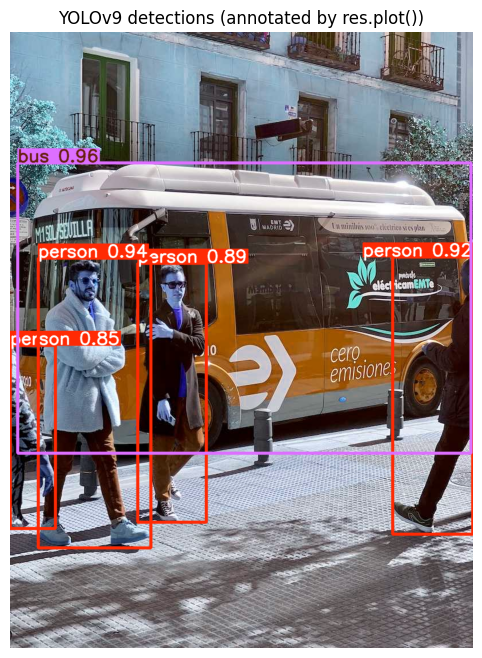

Saved annotated image to: yolov9_annotated.jpg


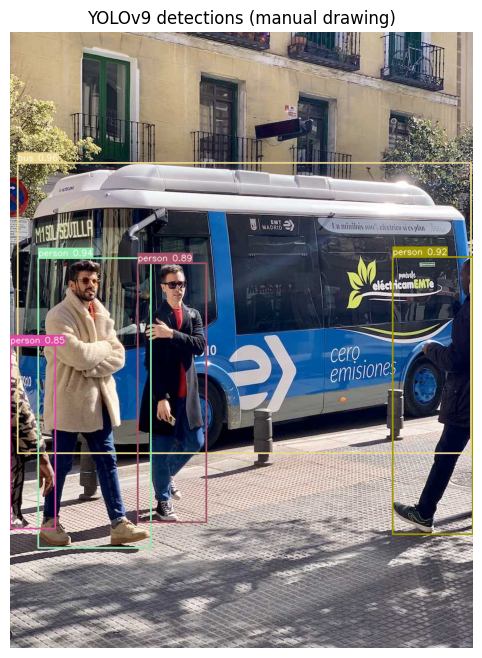

In [8]:
#Q4.  How do you load an image and perform inference using YOLOv9, then display the detected objects with bounding boxes and class labels?

# yolov9_infer_and_display.py
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO

# ---------- CONFIG ----------
WEIGHTS = "yolov9c.pt"   # your YOLOv8/YOLOv9-format weights
IMAGE   = "bus.jpg"   # input image path
CONF    = 0.25                       # confidence threshold
IOU     = 0.45                       # NMS IoU threshold
IMG_SZ  = 640                        # inference size
DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_OUTPUT = True
OUT_PATH = "yolov9_annotated.jpg"
# ----------------------------

# Load model (Ultralytics YOLO API accepts many checkpoint names)
model = YOLO(WEIGHTS)
model.to(DEVICE)
model.fuse()  # optional: fuse conv+bns for speed/efficiency on some checkpoints

# Run prediction (predict gives more control than calling model(...) directly)
results = model.predict(
    source=IMAGE,
    conf=CONF,
    iou=IOU,
    device=DEVICE,
    imgsz=IMG_SZ,
    save=False,    # don't auto-save using Ultralytics runner
    augment=False, # set True for TTA-style augmentations
)

# Get first (and only) result
res = results[0]

# Option A — Use built-in annotator (fast, nice-looking)
annotated_rgb = res.plot()  # RGB numpy array with drawn boxes & labels

# Show with matplotlib
plt.figure(figsize=(12, 8))
plt.axis("off")
plt.imshow(annotated_rgb)
plt.title("YOLOv9 detections (annotated by res.plot())")
plt.show()

if SAVE_OUTPUT:
    # convert (RGB -> BGR) for OpenCV saving
    annotated_bgr = cv2.cvtColor(annotated_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(OUT_PATH, annotated_bgr)
    print("Saved annotated image to:", OUT_PATH)

# Option B — Manual drawing with OpenCV (more control)
# Extract boxes, scores, class ids
if hasattr(res, "boxes") and len(res.boxes) > 0:
    xyxy = res.boxes.xyxy.cpu().numpy()    # Nx4: x1,y1,x2,y2
    conf = res.boxes.conf.cpu().numpy()    # N
    cls  = res.boxes.cls.cpu().numpy().astype(int)  # N
else:
    xyxy = np.zeros((0,4))
    conf = np.zeros((0,))
    cls  = np.zeros((0,), dtype=int)

# Load original image (BGR for OpenCV ops)
img_bgr = cv2.imread(IMAGE)
if img_bgr is None:
    raise FileNotFoundError(f"Couldn't load image at {IMAGE}")

# Prepare class name mapping
class_names = model.names  # dict: id -> label

# Draw each detection
line_thickness = max(round(0.002 * max(img_bgr.shape[0:2])), 1)
for i, box in enumerate(xyxy):
    x1, y1, x2, y2 = map(int, box)
    score = float(conf[i])
    label = class_names.get(int(cls[i]), str(int(cls[i])))
    text = f"{label} {score:.2f}"

    # choose color (BGR)
    color = tuple(int(c) for c in np.random.randint(0, 255, size=3))
    cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color, thickness=line_thickness)

    # text background
    (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, thickness=1)
    cv2.rectangle(img_bgr, (x1, y1 - th - 6), (x1 + tw, y1), color, -1)
    cv2.putText(img_bgr, text, (x1, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), thickness=1, lineType=cv2.LINE_AA)

# Convert to RGB for display in matplotlib
img_rgb_manual = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.axis("off")
plt.imshow(img_rgb_manual)
plt.title("YOLOv9 detections (manual drawing)")
plt.show()

Saved annotated image to: fasterrcnn_annotated.jpg


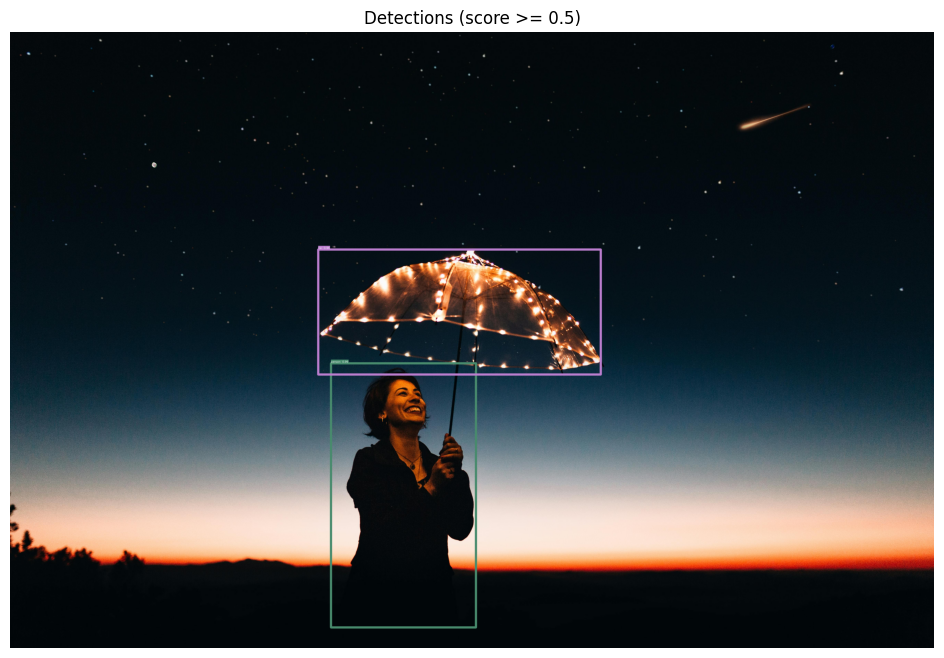


Detections:
01: person  score=0.993  box=[1864.5146484375, 1924.458740234375, 2706.55419921875, 3458.044677734375]
02: tie  score=0.964  box=[1790.9859619140625, 1263.4918212890625, 3431.42236328125, 1989.047119140625]


In [9]:
#Q5. How do you display bounding boxes for the detected objects in an image using Faster RCNN?

# fasterrcnn_draw_boxes.py
import torch
import torchvision
from torchvision import transforms as T
from PIL import Image
import requests
from io import BytesIO
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
IMAGE_URL = "https://images.pexels.com/photos/573238/pexels-photo-573238.jpeg"  # can be a local path too
SCORE_THRESHOLD = 0.5
OUT_PATH = "fasterrcnn_annotated.jpg"
# ----------------------------------------

# Standard COCO category names used by torchvision pretrained models
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__','person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
    'traffic light','fire hydrant','stop sign','parking meter','bench','bird','cat','dog','horse','sheep','cow',
    'elephant','bear','zebra','giraffe','backpack','umbrella','handbag','tie','suitcase','frisbee','skis','snowboard',
    'sports ball','kite','baseball bat','baseball glove','skateboard','surfboard','tennis racket','bottle','wine glass',
    'cup','fork','knife','spoon','bowl','banana','apple','sandwich','orange','broccoli','carrot','hot dog','pizza','donut',
    'cake','chair','couch','potted plant','bed','dining table','toilet','tv','laptop','mouse','remote','keyboard','cell phone',
    'microwave','oven','toaster','sink','refrigerator','book','clock','vase','scissors','teddy bear','hair drier','toothbrush'
]

def load_image_from_url(url):
    resp = requests.get(url)
    resp.raise_for_status()
    img = Image.open(BytesIO(resp.content)).convert("RGB")
    return img

def load_image_from_path(path):
    img = Image.open(path).convert("RGB")
    return img

def draw_boxes_on_image_bgr(img_bgr, boxes, labels, scores):
    """
    img_bgr: numpy array in BGR (OpenCV) format
    boxes: Nx4 array of floats (x1,y1,x2,y2)
    labels: list/array of ints
    scores: list/array of floats
    """
    h, w = img_bgr.shape[:2]
    thickness = max(1, int(round(0.002 * max(h, w))))
    for box, lbl, scr in zip(boxes, labels, scores):
        x1, y1, x2, y2 = [int(x) for x in box]
        class_name = COCO_INSTANCE_CATEGORY_NAMES[lbl] if lbl < len(COCO_INSTANCE_CATEGORY_NAMES) else str(lbl)
        text = f"{class_name}: {scr:.2f}"

        color = tuple(int(c) for c in np.random.randint(0, 255, size=3).tolist())
        # rectangle
        cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color, thickness=thickness)

        # text background
        (tw, th), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, thickness=1)
        cv2.rectangle(img_bgr, (x1, y1 - th - baseline - 4), (x1 + tw, y1), color, -1)
        cv2.putText(img_bgr, text, (x1, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), thickness=1, lineType=cv2.LINE_AA)

    return img_bgr

def main():
    # 1) Load model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    model.to(device)
    model.eval()

    # 2) Load image (URL or local path)
    # If you want to use a local path, replace load_image_from_url(...) with load_image_from_path(local_path)
    pil_img = load_image_from_url(IMAGE_URL)

    # keep a copy for drawing in original resolution
    orig_w, orig_h = pil_img.size
    img_cv = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

    # 3) Preprocess
    transform = T.Compose([T.ToTensor()])  # Faster R-CNN expects tensors in [0,1]
    img_tensor = transform(pil_img).to(device)

    # 4) Inference
    with torch.no_grad():
        outputs = model([img_tensor])  # list of dicts
    out = outputs[0]

    # 5) Extract detections and filter by score
    boxes = out['boxes'].cpu().numpy()       # Nx4
    scores = out['scores'].cpu().numpy()     # N
    labels = out['labels'].cpu().numpy()     # N

    keep_idxs = np.where(scores >= SCORE_THRESHOLD)[0]

    boxes = boxes[keep_idxs]
    scores = scores[keep_idxs]
    labels = labels[keep_idxs]

    # 6) Draw boxes
    annotated_bgr = draw_boxes_on_image_bgr(img_cv.copy(), boxes, labels, scores)

    # 7) Save and display
    cv2.imwrite(OUT_PATH, annotated_bgr)
    print(f"Saved annotated image to: {OUT_PATH}")

    # Convert to RGB for matplotlib display
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12,8))
    plt.axis('off')
    plt.imshow(annotated_rgb)
    plt.title(f"Detections (score >= {SCORE_THRESHOLD})")
    plt.show()

    # 8) Print textual detections
    print("\nDetections:")
    for i, (b, l, s) in enumerate(zip(boxes, labels, scores)):
        print(f"{i+1:02d}: {COCO_INSTANCE_CATEGORY_NAMES[l]}  score={s:.3f}  box={b.tolist()}")

if __name__ == "__main__":
    main()


In [11]:
#Q6. How do you perform inference on a local image using Faster RCNN?

import torch
import torchvision
from torchvision import transforms as T
from PIL import Image
import numpy as np

# ----------------------------
# CONFIG
# ----------------------------
IMAGE_PATH = "bus.jpg"  # Updated to use the existing bus.jpg
SCORE_THRESHOLD = 0.5  # display predictions above this confidence

# COCO class names for Faster R-CNN pretrained model
COCO_CLASSES = [
    '__background__','person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
    'traffic light','fire hydrant','stop sign','parking meter','bench','bird','cat','dog','horse','sheep','cow',
    'elephant','bear','zebra','giraffe','backpack','umbrella','handbag','tie','suitcase','frisbee','skis','snowboard',
    'sports ball','kite','baseball bat','baseball glove','skateboard','surfboard','tennis racket','bottle','wine glass',
    'cup','fork','knife','spoon','bowl','banana','apple','sandwich','orange','broccoli','carrot','hot dog','pizza','donut',
    'cake','chair','couch','potted plant','bed','dining table','toilet','tv','laptop','mouse','remote','keyboard','cell phone',
    'microwave','oven','toaster','sink','refrigerator','book','clock','vase','scissors','teddy bear','hair drier','toothbrush'
]

# ----------------------------
# 1. Load Model
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
model.to(device)
model.eval()

# ----------------------------
# 2. Load Local Image
# ----------------------------
img = Image.open(IMAGE_PATH).convert("RGB")

# Transform: Faster R-CNN expects tensor in [0,1]
transform = T.Compose([T.ToTensor()])
img_tensor = transform(img).to(device)

# ----------------------------
# 3. Inference
# ----------------------------
with torch.no_grad():
    outputs = model([img_tensor])  # list of outputs, one per image

pred = outputs[0]

# ----------------------------
# 4. Extract predictions
# ----------------------------
boxes = pred["boxes"].cpu().numpy()
scores = pred["scores"].cpu().numpy()
labels = pred["labels"].cpu().numpy()

print("\n===== DETECTIONS =====")
for box, score, label in zip(boxes, scores, labels):
    if score < SCORE_THRESHOLD:
        continue

    class_name = COCO_CLASSES[label] if label < len(COCO_CLASSES) else str(label)
    print(f"Class: {class_name}")
    print(f"Confidence: {score:.3f}")
    print(f"Bounding Box: {box.tolist()}")
    print("------------------------")


===== DETECTIONS =====
Class: person
Confidence: 0.998
Bounding Box: [223.9960174560547, 410.019287109375, 352.48187255859375, 861.1489868164062]
------------------------
Class: person
Confidence: 0.996
Bounding Box: [47.942657470703125, 401.9920654296875, 246.22216796875, 903.385498046875]
------------------------
Class: bus
Confidence: 0.990
Bounding Box: [23.15587043762207, 235.28639221191406, 800.555419921875, 784.008056640625]
------------------------
Class: person
Confidence: 0.984
Bounding Box: [673.7278442382812, 463.5787353515625, 810.0000610351562, 877.5505981445312]
------------------------
Class: person
Confidence: 0.971
Bounding Box: [0.7443928718566895, 556.4996948242188, 67.2044906616211, 876.5228881835938]
------------------------


In [13]:
#Q7. How can you change the confidence threshold for YOLO object detection and filter out low-confidence predictions?

from ultralytics import YOLO
import numpy as np
import cv2

# Load model (YOLOv8 or custom 'yolov9.pt' weights)
# Corrected: Use 'yolov9c.pt' as downloaded previously
model = YOLO("yolov9c.pt")

# Corrected: Use 'bus.jpg' as downloaded previously
IMAGE_SOURCE = "bus.jpg"

# Set confidence threshold (e.g., 0.4 = 40%)
# This is the confidence for the 'predict' method itself.
results_direct_predict = model.predict(
    source=IMAGE_SOURCE,
    conf=0.40,        # 🔥 confidence threshold for direct prediction
    iou=0.45,
    imgsz=640,
    save=False # Do not auto-save, we'll do it manually if needed
)

# Show predictions from the direct predict call (optional)
# results_direct_predict[0].show()

# Now, demonstrate filtering with a custom threshold after initial prediction
# Initial prediction with a lower threshold to capture more boxes for filtering
results_for_filter = model(IMAGE_SOURCE, conf=0.25)  # initial low threshold

res = results_for_filter[0]

# Extract data
boxes = res.boxes
xyxy = boxes.xyxy.cpu().numpy()
confs = boxes.conf.cpu().numpy()
classes = boxes.cls.cpu().numpy().astype(int)

# Custom threshold for filtering after inference
CONF_THRESH = 0.50   # 🔥 set your desired threshold here for post-inference filtering

# Filter predictions based on the custom threshold
keep = confs >= CONF_THRESH
xyxy_filtered = xyxy[keep]
confs_filtered = confs[keep]
classes_filtered = classes[keep]

print("Filtered Predictions (Confidence >= {CONF_THRESH:.2f}):")
if len(xyxy_filtered) == 0:
    print("No objects detected above the confidence threshold.")
else:
    for box, conf, cls in zip(xyxy_filtered, confs_filtered, classes_filtered):
        print(f"Class: {model.names[cls]}, Conf: {conf:.3f}, Box: {box.tolist()}")

# Visualize the filtered predictions on the image
img = cv2.imread(IMAGE_SOURCE)
if img is None:
    raise FileNotFoundError(f"Couldn't load image at {IMAGE_SOURCE}")

# Get class names from the model
class_names = model.names

for box, conf, cls in zip(xyxy_filtered, confs_filtered, classes_filtered):
    x1, y1, x2, y2 = box.astype(int)
    label = f"{class_names[cls]} {conf:.2f}"

    # Draw rectangle and text
    color = (0, 255, 0) # Green color for bounding box
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

    # Get text size for background rectangle
    (text_width, text_height), baseline = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
    cv2.rectangle(img, (x1, y1 - text_height - baseline), (x1 + text_width, y1), color, -1)
    cv2.putText(img, label, (x1, y1 - baseline), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)

output_image_path = "filtered_output.jpg"
cv2.imwrite(output_image_path, img)
print(f"Saved filtered image: {output_image_path}")


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1764.5ms
Speed: 6.0ms preprocess, 1764.5ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)

image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1500.4ms
Speed: 2.8ms preprocess, 1500.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)
Filtered Predictions (Confidence >= {CONF_THRESH:.2f}):
Class: bus, Conf: 0.956, Box: [13.521011352539062, 229.8277587890625, 806.1673583984375, 738.55029296875]
Class: person, Conf: 0.940, Box: [49.23675537109375, 396.3540344238281, 246.54417419433594, 904.1870727539062]
Class: person, Conf: 0.915, Box: [669.8377075195312, 394.8587951660156, 809.6011962890625, 880.367919921875]
Class: person, Conf: 0.893, Box: [223.64442443847656, 405.714111328125, 343.51788330078125, 859.3513793945312]
Class: person, Conf: 0.848, Box: [0.1729574203491211, 549.5196533203125, 79.16455841064453, 870.73681640625]
Saved filtered image: filtered_output.jpg


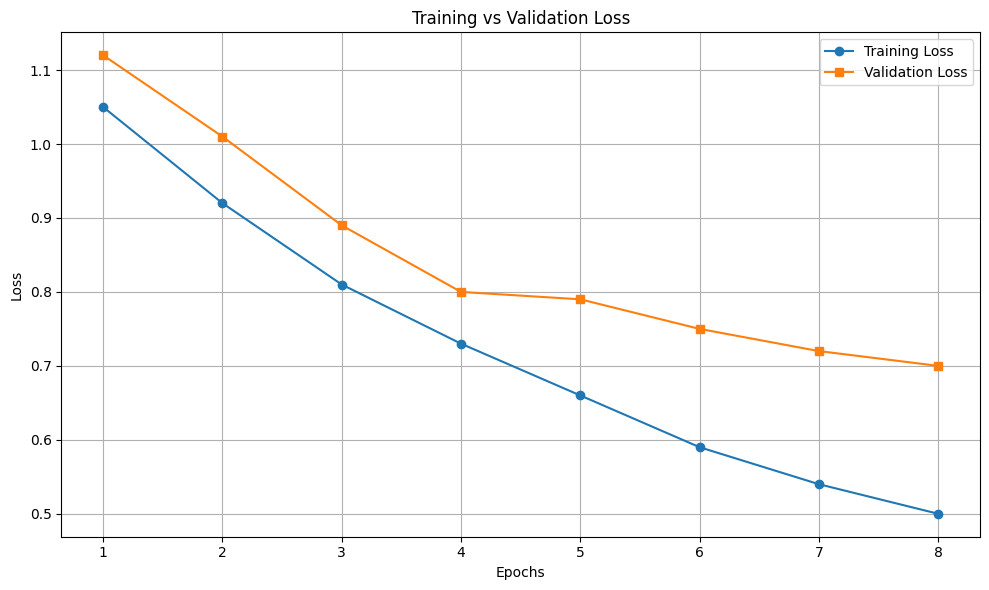

In [15]:
#Q8. How do you plot the training and validation loss curves for model evaluation?

import matplotlib.pyplot as plt

# Example: lists of loss values recorded during training
training_loss = [1.05, 0.92, 0.81, 0.73, 0.66, 0.59, 0.54, 0.50]
validation_loss = [1.12, 1.01, 0.89, 0.80, 0.79, 0.75, 0.72, 0.70]

epochs = range(1, len(training_loss) + 1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, training_loss, label="Training Loss", marker='o')
plt.plot(epochs, validation_loss, label="Validation Loss", marker='s')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
#Q9. How do you perform inference on multiple images from a local folder using Faster RCNN and display the bounding boxes for each?

"""
fasterrcnn_batch_infer.py

Requirements:
  pip install torch torchvision pillow opencv-python matplotlib
"""

import os
import torch
import torchvision
from torchvision import transforms as T
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt

# --------- CONFIG ----------
IMAGE_FOLDER = "images"       # folder with input images
OUT_FOLDER   = "outputs"      # folder to save annotated images
BATCH_SIZE   = 4              # number of images to run per forward pass (adjust by GPU memory)
SCORE_THRESHOLD = 0.5         # confidence threshold to keep detections
SHOW_IMAGES = False           # True to display images with matplotlib
# ---------------------------

# COCO class names (index -> label) used by torchvision models
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__','person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
    'traffic light','fire hydrant','stop sign','parking meter','bench','bird','cat','dog','horse','sheep','cow',
    'elephant','bear','zebra','giraffe','backpack','umbrella','handbag','tie','suitcase','frisbee','skis','snowboard',
    'sports ball','kite','baseball bat','baseball glove','skateboard','surfboard','tennis racket','bottle','wine glass',
    'cup','fork','knife','spoon','bowl','banana','apple','sandwich','orange','broccoli','carrot','hot dog','pizza','donut',
    'cake','chair','couch','potted plant','bed','dining table','toilet','tv','laptop','mouse','remote','keyboard','cell phone',
    'microwave','oven','toaster','sink','refrigerator','book','clock','vase','scissors','teddy bear','hair drier','toothbrush'
]

# Create the IMAGE_FOLDER if it doesn't exist and move 'bus.jpg' into it
os.makedirs(IMAGE_FOLDER, exist_ok=True)
if os.path.exists("bus.jpg") and not os.path.exists(os.path.join(IMAGE_FOLDER, "bus.jpg")):
    os.rename("bus.jpg", os.path.join(IMAGE_FOLDER, "bus.jpg"))
    print(f"Moved bus.jpg to {IMAGE_FOLDER}/")

os.makedirs(OUT_FOLDER, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load pretrained Faster R-CNN with ResNet-50 FPN
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
model.to(device)
model.eval()

# Simple transforms: PIL -> tensor in [0,1]
transform = T.Compose([T.ToTensor()])

# Helper: draw boxes on OpenCV BGR image
def draw_boxes_cv2(img_bgr, boxes, labels, scores):
    h, w = img_bgr.shape[:2]
    thickness = max(1, int(round(0.002 * max(h, w))))
    for box, lbl, scr in zip(boxes, labels, scores):
        x1, y1, x2, y2 = [int(x) for x in box]
        class_name = COCO_INSTANCE_CATEGORY_NAMES[lbl] if lbl < len(COCO_INSTANCE_CATEGORY_NAMES) else str(lbl)
        text = f"{class_name}: {scr:.2f}"
        color = (int(255 * (lbl % 3 == 0)), int(255 * (lbl % 3 == 1)), int(255 * (lbl % 3 == 2)))  # deterministic color
        cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color, thickness=thickness)
        # text background
        (tw, th), baseline = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, thickness=1)
        cv2.rectangle(img_bgr, (x1, y1 - th - baseline - 4), (x1 + tw, y1), color, -1)
        cv2.putText(img_bgr, text, (x1, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), thickness=1, lineType=cv2.LINE_AA)
    return img_bgr

# Gather image paths
valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}
image_paths = [os.path.join(IMAGE_FOLDER, f) for f in sorted(os.listdir(IMAGE_FOLDER))
               if os.path.splitext(f.lower())[1] in valid_exts]

if not image_paths:
    raise SystemExit(f"No images found in {IMAGE_FOLDER} (supported ext: {valid_exts})")

# Process in batches
for i in range(0, len(image_paths), BATCH_SIZE):
    batch_paths = image_paths[i : i + BATCH_SIZE]

    pil_images = []
    orig_bgrs = []
    for p in batch_paths:
        pil = Image.open(p).convert("RGB")
        pil_images.append(pil)
        orig_bgrs.append(cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR))

    # Prepare tensors and move to device
    tensors = [transform(img).to(device) for img in pil_images]

    # Forward pass (list input)
    with torch.no_grad():
        outputs = model(tensors)  # list of dicts, same order as tensors

    # Iterate results and draw/save
    for path, out, orig_bgr in zip(batch_paths, outputs, orig_bgrs):
        boxes = out["boxes"].cpu().numpy()
        scores = out["scores"].cpu().numpy()
        labels = out["labels"].cpu().numpy()

        keep = scores >= SCORE_THRESHOLD
        boxes = boxes[keep]
        scores = scores[keep]
        labels = labels[keep]

        annotated = draw_boxes_cv2(orig_bgr.copy(), boxes, labels, scores)
        fname = os.path.basename(path)
        out_path = os.path.join(OUT_FOLDER, fname)
        cv2.imwrite(out_path, annotated)
        print(f"Saved: {out_path}  (detections: {len(boxes)})")

        if SHOW_IMAGES:
            # convert to RGB for matplotlib
            annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(10, 6))
            plt.axis("off")
            plt.imshow(annotated_rgb)
            plt.title(f"{fname} - {len(boxes)} detections")
            plt.show()

print("Done.")

Moved bus.jpg to images/
Using device: cpu
Saved: outputs/bus.jpg  (detections: 5)
Done.


Saved annotated image to: fasterrcnn_with_scores.jpg


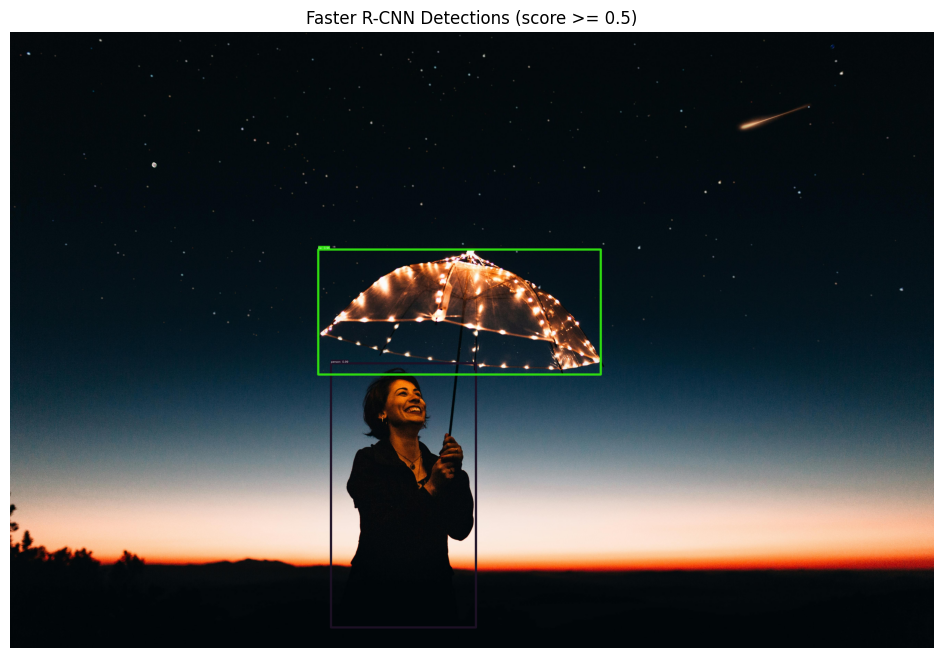


Detections:
01: person          score=0.993  box=['1864.51', '1924.46', '2706.55', '3458.04']
02: tie             score=0.964  box=['1790.99', '1263.49', '3431.42', '1989.05']


In [21]:
#Q10. How do you visualize the confidence scores alongside the bounding boxes for detected objects using Faster RCNN?

# fasterrcnn_visualize_scores.py
import torch
import torchvision
from torchvision import transforms as T
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import requests
from io import BytesIO
import os

# ---------------- CONFIG ----------------
IMAGE_PATH_OR_URL = "https://images.pexels.com/photos/573238/pexels-photo-573238.jpeg"   # Using an online image
SCORE_THRESHOLD = 0.5
OUT_PATH = "fasterrcnn_with_scores.jpg"
# ----------------------------------------

# COCO class names (index -> label)
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__','person','bicycle','car','motorcycle','airplane','bus','train','truck','boat',
    'traffic light','fire hydrant','stop sign','parking meter','bench','bird','cat','dog','horse','sheep','cow',
    'elephant','bear','zebra','giraffe','backpack','umbrella','handbag','tie','suitcase','frisbee','skis','snowboard',
    'sports ball','kite','baseball bat','baseball glove','skateboard','surfboard','tennis racket','bottle','wine glass',
    'cup','fork','knife','spoon','bowl','banana','apple','sandwich','orange','broccoli','carrot','hot dog','pizza','donut',
    'cake','chair','couch','potted plant','bed','dining table','toilet','tv','laptop','mouse','remote','keyboard','cell phone',
    'microwave','oven','toaster','sink','refrigerator','book','clock','vase','scissors','teddy bear','hair drier','toothbrush'
]

def load_image(path_or_url):
    if str(path_or_url).lower().startswith("http"):
        resp = requests.get(path_or_url)
        resp.raise_for_status()
        pil = Image.open(BytesIO(resp.content)).convert("RGB")
    else:
        pil = Image.open(path_or_url).convert("RGB")
    return pil

def draw_boxes_with_scores(img_bgr, boxes, labels, scores, score_thresh=0.5):
    """
    img_bgr: OpenCV BGR image (numpy)
    boxes: Nx4 array (x1,y1,x2,y2)
    labels: Nx ints
    scores: N floats
    """
    h, w = img_bgr.shape[:2]
    line_thickness = max(1, int(round(0.002 * max(h, w))))
    for box, lbl, scr in zip(boxes, labels, scores):
        if scr < score_thresh:
            continue
        x1, y1, x2, y2 = [int(v) for v in box]
        class_name = COCO_INSTANCE_CATEGORY_NAMES[lbl] if lbl < len(COCO_INSTANCE_CATEGORY_NAMES) else str(lbl)
        label_text = f"{class_name}: {scr:.2f}"

        # deterministic color by class id
        color = tuple(int(c) for c in np.array([(lbl * 37) % 255, (lbl * 17) % 255, (lbl * 29) % 255], dtype=np.uint8))

        # draw rectangle
        cv2.rectangle(img_bgr, (x1, y1), (x2, y2), color, thickness=line_thickness)

        # compute text size
        (tw, th), baseline = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, thickness=1)
        # draw text background
        cv2.rectangle(img_bgr, (x1, y1 - th - baseline - 4), (x1 + tw, y1), color, -1)
        # draw text
        cv2.putText(img_bgr, label_text, (x1, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), thickness=1, lineType=cv2.LINE_AA)

    return img_bgr

def main():
    # 1) Load model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    model.to(device)
    model.eval()

    # 2) Load image (URL or local path)
    pil_img = load_image(IMAGE_PATH_OR_URL)

    # keep a copy for drawing in original resolution
    img_cv = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

    # 3) Preprocess
    transform = T.Compose([T.ToTensor()])  # Faster R-CNN expects tensors in [0,1]
    img_tensor = transform(pil_img).to(device)

    # 4) Inference
    with torch.no_grad():
        outputs = model([img_tensor])  # list of dicts
    out = outputs[0]

    # 5) Extract detections and filter by score
    boxes = out['boxes'].cpu().numpy()       # Nx4
    scores = out['scores'].cpu().numpy()     # N
    labels = out['labels'].cpu().numpy()     # N

    # 6) Draw boxes with scores
    annotated_bgr = draw_boxes_with_scores(img_cv.copy(), boxes, labels, scores, SCORE_THRESHOLD)

    # 7) Save and display
    cv2.imwrite(OUT_PATH, annotated_bgr)
    print(f"Saved annotated image to: {OUT_PATH}")

    # Convert to RGB for matplotlib display
    annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12,8))
    plt.axis('off')
    plt.imshow(annotated_rgb)
    plt.title(f"Faster R-CNN Detections (score >= {SCORE_THRESHOLD})")
    plt.show()

    # 8) Print textual detections
    print("\nDetections:")
    for i, (b, l, s) in enumerate(zip(boxes, labels, scores)):
        if s >= SCORE_THRESHOLD:
            class_name = COCO_INSTANCE_CATEGORY_NAMES[l] if l < len(COCO_INSTANCE_CATEGORY_NAMES) else str(l)
            print(f"{i+1:02d}: {class_name:<15} score={s:.3f}  box={[f'{x:.2f}' for x in b.tolist()]}")

if __name__ == "__main__":
    main()

In [23]:
#Q11. How can you save the inference results (with bounding boxes) as a new image after performing detection using YOLO?

from ultralytics import YOLO
import cv2

# ------------------------------------
# Load YOLO model (YOLOv8 or custom YOLOv9)
# ------------------------------------
model = YOLO("yolov9c.pt")   # Corrected to use the downloaded yolov9c.pt

# ------------------------------------
# Run Inference
# ------------------------------------
results = model("images/bus.jpg", conf=0.25) # Corrected path to bus.jpg

# Get the first (and only) result
res = results[0]

# ------------------------------------
# Get the annotated image (RGB numpy array)
# ------------------------------------
annotated_img = res.plot()

# Convert RGB -> BGR for OpenCV saving
annotated_bgr = cv2.cvtColor(annotated_img, cv2.COLOR_RGB2BGR)

# ------------------------------------
# Save output image
# ------------------------------------
output_path = "output_annotated.jpg"
cv2.imwrite(output_path, annotated_bgr)

print("Saved annotated image to:", output_path)



image 1/1 /content/images/bus.jpg: 640x480 4 persons, 1 bus, 1516.5ms
Speed: 4.6ms preprocess, 1516.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 480)
Saved annotated image to: output_annotated.jpg
